In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from plotly import express as px
from plotly import graph_objects as go

In [180]:
flat_df=pd.read_csv("apartments.csv")
house_df=pd.read_csv("houses.csv")

In [181]:
flat_df.drop_duplicates(inplace=True)

In [182]:
flat_df.duplicated().sum()

np.int64(0)

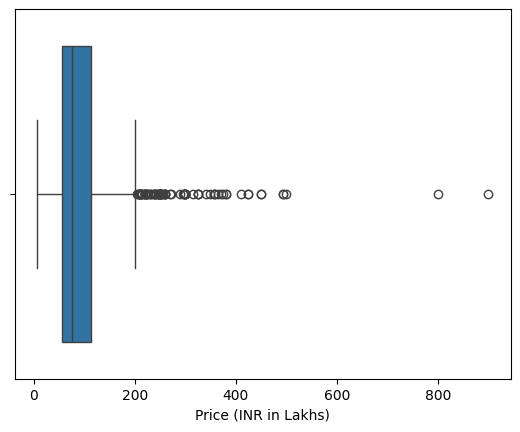

In [183]:
# sns.displot(flat_df['Price (INR in Lakhs)'])
# sns.displot(np.log1p(flat_df['Price (INR in Lakhs)']),kde=True)

sns.boxplot(x=flat_df['Price (INR in Lakhs)'])
plt.show()

In [184]:
pd.set_option('display.max_colwidth', None)

In [185]:
flat_df[flat_df['Price (INR in Lakhs)']>600][['Name','Price (INR in Lakhs)','Price_per_sqft','Area_sqft','bedrooms','Property_URL']]

,Name,Price (INR in Lakhs),Price_per_sqft,Area_sqft,bedrooms,Property_URL
954,"3 BHK Builder Floorin Randesan, Gandhinagar",900.0,46153.0,1950.0,3.0,https://www.99acres.com/3-bhk-bedroom-independent-builder-floor-for-sale-in-randesan-gandhinagar-1950-sqft-spid-P89601178
1011,"3 BHK Builder Floorin Kudasan, Gandhinagar",800.0,42328.0,1890.0,3.0,https://www.99acres.com/3-bhk-bedroom-independent-builder-floor-for-sale-in-shree-krishna-sunshine-heights-2-kudasan-gandhinagar-1890-sqft-spid-J88918994


In [186]:
flat_df['log_price']=np.log1p(flat_df['Price (INR in Lakhs)'])

In [187]:
Q1=flat_df['Price (INR in Lakhs)'].quantile(0.25)
Q3=flat_df['Price (INR in Lakhs)'].quantile(0.75)
IQR=Q3-Q1
lower_bound=Q1-1.5*IQR
upper_bound=Q3+1.5*IQR
outliers=flat_df[(flat_df['Price (INR in Lakhs)']<lower_bound) | (flat_df['Price (INR in Lakhs)']>upper_bound)]
print(outliers.shape)
outliers['Price (INR in Lakhs)'].describe()

(81, 24)


count     81.000000
mean     298.148148
std      116.366137
min      205.000000
25%      229.000000
50%      251.000000
75%      326.000000
max      900.000000
Name: Price (INR in Lakhs), dtype: float64

In [189]:
log_price=flat_df['log_price']
mean=log_price.mean()
std=log_price.std()
outliers=flat_df[(log_price < mean - 3*std) | (log_price > mean + 3*std)]
print(outliers.shape)
outliers['Price (INR in Lakhs)'].describe()

(11, 24)


count     11.000000
mean     295.250000
std      350.682353
min        7.000000
25%       10.125000
50%       11.500000
75%      497.000000
max      900.000000
Name: Price (INR in Lakhs), dtype: float64

In [190]:
outliers.sample(11)

,Name,Location,Price (INR in Lakhs),Price_per_sqft,Area_sqft,Description,Property_URL,bedrooms,bathrooms,balconies,...,facing,property_age_bucket,is_ready_to_move,is_built_up_area,is_carpet_area,is_super_built_up_area,property_type,luxury_score,location_advantage_score,log_price
538,"4 BHK Flatin Gift City, Gandhinagar","Gift City, Gandhinagar",494.00,14269.0,3462.0,"The 4 bhk duplex residences at sobha elysia are exclusive, ultra-Spacious homes esigned across two levels, offering enhanced privacy and a villa-Like living experience.Located in gift city, they provide access to world-Class amenities such as a sky lounge, clubhouse, and landscaped leisure zones, ensuring a sophisticated and elevated lifestyle.",https://www.99acres.com/4-bhk-bedroom-apartment-flat-for-sale-in-sobha-elysia-gift-city-gandhinagar-3462-sqft-spid-T89987786,4.0,4.0,2.0,...,NaN,New,0,False,False,True,apartment,11.0,0.0,6.204558
1103,"Studio Apartments / 1 RK Flatsin Kalol, Gandhinagar","Kalol, Gandhinagar",10.00,3413.0,293.0,"1 rk studio apartment with 1 balcony and bathroom in kalol, 293 sq. Ft carpet area sell price 10 negotiable , 6 year old",https://www.99acres.com/studio-apartment-flat-for-sale-in-tata-shubh-griha-kalol-gandhinagar-293-sqft-spid-F88142122,0.0,1.0,1.0,...,NaN,Unknown,1,False,True,False,apartment,0.0,0.0,2.397895
1101,"Studio Apartments / 1 RK Flatsin Kalol, Gandhinagar","Kalol, Gandhinagar",10.25,3498.0,293.0,"1 rk with balcony with bathroom available in kalol, 293 sq. Ft carpet area for sell price 10.25 lac negotiable and property on 2nd floor out of 5 floor and 6 year old",https://www.99acres.com/studio-apartment-flat-for-sale-in-tata-shubh-griha-kalol-gandhinagar-293-sqft-spid-K88143114,1.0,1.0,1.0,...,NaN,Unknown,1,False,True,False,apartment,0.0,0.0,2.420368
1011,"3 BHK Builder Floorin Kudasan, Gandhinagar","Kudasan, Gandhinagar",800.00,42328.0,1890.0,"I have a builder floor available for sale in kudasan, gandhinagar. Available at price of rs 8 crores. It has super area of 210 sq yards. It has 3 bhk, 3 bathroom, 2 balcony.It is a freehold property",https://www.99acres.com/3-bhk-bedroom-independent-builder-floor-for-sale-in-shree-krishna-sunshine-heights-2-kudasan-gandhinagar-1890-sqft-spid-J88918994,3.0,3.0,2.0,...,NaN,Unknown,0,False,False,True,builder floor,0.0,0.0,6.685861
1105,"Studio Apartments / 1 RK Flatsin Chhatral, Gandhinagar","Chhatral, Gandhinagar",7.00,1728.0,405.0,"1 rk studio apartment 1 bathroom available in chhatral, gandhinagar for sell 7 lac negotiable for 45 sq. Yard carpet area. Property on 2nd floor out of 3 floor",https://www.99acres.com/studio-apartment-flat-for-sale-in-chhatral-gandhinagar-405-sqft-spid-K88135910,1.0,1.0,1.0,...,NaN,New,1,False,True,False,apartment,0.0,0.0,2.079442
1100,"Studio Apartments / 1 RK Flatsin Kalol, Gandhinagar","Kalol, Gandhinagar",10.00,2222.0,450.0,"1 rk studio apartment available with 1 balcony in kalol, for 50 sq. Yard carpet area, for sell 10 lac negotiable 6 year old , 2nd floor property out of 5 floor",https://www.99acres.com/studio-apartment-flat-for-sale-in-tata-shubh-griha-kalol-gandhinagar-450-sqft-spid-N88143212,0.0,1.0,1.0,...,NaN,Unknown,1,False,True,False,apartment,0.0,0.0,2.397895
140,"6 BHK Flatin Sargasan, Gandhinagar","Sargasan, Gandhinagar",500.00,5555.0,9000.0,"This 6 bhk flat spans 9,000 sq.Ft. On the 10th floor of a mid-Rise building at atulyam the imperial, sargasan, gandhinagar. Available immediately, its 1-5 years old and features 5 bathrooms, a swimming pool, lift access, and is unfurnished. Conveniently located near top schools, hospitals, and the sarkhej gandhinagar highway.",https://www.99acres.com/6-bhk-bedroom-apartment-flat-for-sale-in-atulyam-the-imperial-sargasan-gandhinagar-9000-sq-ft-spid-F90780200,6.0,5.0,2.0,...,NaN,1-5 years,1,False,True,False,apartment,4.0,2.0,6.216606
629,"4 BHK Flatin Gift City, Gandhinagar","Gift City, Gandhinagar",494.00,14256.0,3462.0,"Sobha elysia redefines international living with its sleek modern facade and sta

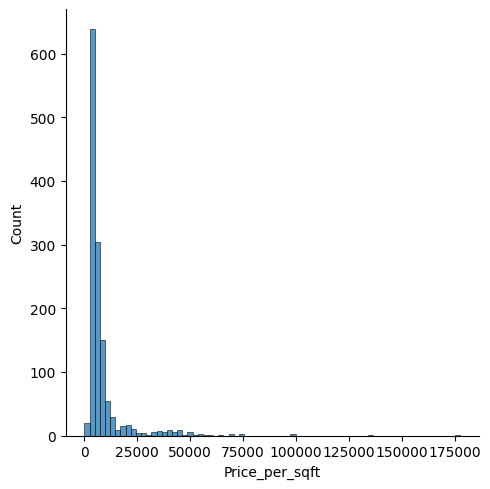

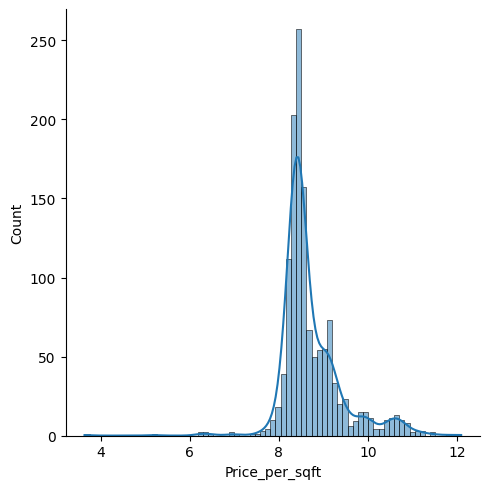

In [193]:
sns.displot(flat_df['Price_per_sqft'])
sns.displot(np.log1p(flat_df['Price_per_sqft']),kde=True)
plt.show()

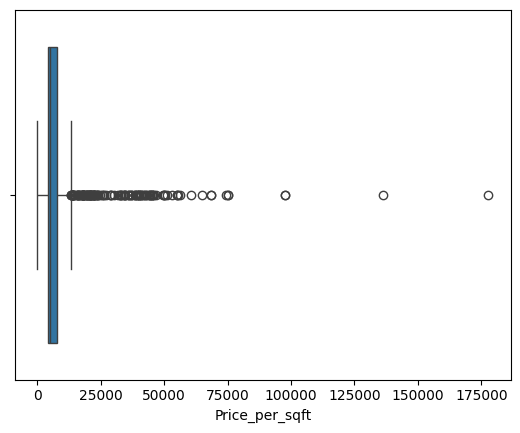

In [194]:
sns.boxplot(x=flat_df['Price_per_sqft'])
plt.show()

In [197]:
Q1 = flat_df['Price_per_sqft'].quantile(0.25)
Q3 = flat_df['Price_per_sqft'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
outliers = flat_df[
    (flat_df['Price_per_sqft'] < lower) |
    (flat_df['Price_per_sqft'] > upper)
]
print("Number of outliers:", len(outliers))
outliers['Price_per_sqft'].describe()

Number of outliers: 139


count       139.000000
mean      33572.669065
std       22731.257759
min       13322.000000
25%       18378.000000
50%       26150.000000
75%       41817.500000
max      177777.000000
Name: Price_per_sqft, dtype: float64

In [198]:
flat_df['Price_per_sqft'].describe()

count      1318.000000
mean       8447.948407
std       11529.084228
min          37.000000
25%        4208.000000
50%        4913.000000
75%        7847.500000
max      177777.000000
Name: Price_per_sqft, dtype: float64

In [199]:
log_pps=np.log1p(flat_df['Price_per_sqft'])
mean=log_pps.mean()
std=log_pps.std()
outliers=flat_df[(log_pps < mean - 3*std) | (log_pps > mean + 3*std)]
print("Number of outliers:", len(outliers))
outliers['Price_per_sqft'].describe()

Number of outliers: 28


count        28.000000
mean      54435.607143
std       42133.704377
min          37.000000
25%       37208.500000
50%       55101.500000
75%       69852.500000
max      177777.000000
Name: Price_per_sqft, dtype: float64

In [201]:
outliers[['Name','Price (INR in Lakhs)','Price_per_sqft','Area_sqft','bedrooms','Property_URL','is_super_built_up_area','is_built_up_area','is_carpet_area']]

,Name,Price (INR in Lakhs),Price_per_sqft,Area_sqft,bedrooms,Property_URL,is_super_built_up_area,is_built_up_area,is_carpet_area
130,"2 BHK Flatin Sargasan, Gandhinagar",70.0,596.0,11743.524,2.0,https://www.99acres.com/2-bhk-bedroom-apartment-flat-for-sale-in-swagat-queens-land-sargasan-gandhinagar-11745-sqft-spid-P90922140,True,False,False
144,"2 BHK Flatin Sargasan, Gandhinagar",58.0,523.0,11097.000,0.0,https://www.99acres.com/2-bhk-bedroom-apartment-flat-for-sale-in-swagat-flamingo-sargasan-gandhinagar-11097-sqft-spid-N90738336,True,False,False
196,"1 BHK Flatin Sector 5A Gandhinagar, Sector 5 Gandhinagar",160.0,177777.0,98.000,1.0,https://www.99acres.com/1-bhk-bedroom-apartment-flat-for-sale-in-sector-5a-gandhinagar-98-sqft-spid-G89932518,False,True,False
207,"1 BHK Triplex Builder Floorin Kalol, Gandhinagar",60.0,37.0,163350.000,1.0,https://www.99acres.com/1-bhk-bedroom-independent-builder-floor-for-sale-in-pk-simandhar-avenue-kalol-gandhinagar-163380-sqft-spid-T89833356,False,False,True
209,"3 BHK Builder Floorin Sargasan, Gandhinagar",140.0,68292.0,204.516,3.0,https://www.99acres.com/3-bhk-bedroom-independent-builder-floor-for-sale-in-sargasan-gandhinagar-205-sqft-spid-Y89824530,False,False,False
210,"3 BHK Builder Floorin Sargasan, Gandhinagar",140.0,68292.0,204.516,3.0,https://www.99acres.com/3-bhk-bedroom-independent-builder-floor-for-sale-in-sargasan-gandhinagar-205-sqft-spid-Y89824248,False,False,False
227,"2 BHK Flatin Sector 22, Gandhinagar",450.0,136363.0,330.000,2.0,https://www.99acres.com/2-bhk-bedroom-apartment-flat-for-sale-in-sector-22-gandhinagar-330-sqft-spid-G89433032,False,False,True
284,"3 BHK Builder Floorin Pethapur, Gandhinagar",35.0,55362.0,63.000,2.0,https://www.99acres.com/3-bhk-bedroom-independent-builder-floor-for-sale-in-pethapur-gandhinagar-63-sqft-spid-L87717098,False,False,True
371,"2 BHK Flatin Kudasan, Gandhinagar",55.0,56122.0,98.000,2.0,https://www.99acres.com/2-bhk-bedroom-apartment-flat-for-sale-in-siddhidhata-astha-kudasan-gandhinagar-98-sqft-spid-Y90788720,False,False,True
436,"3 BHK Flatin Randesan, Gandhinagar",130.0,50980.0,255.000,3.0,https://www.99acres.com/3-bhk-bedroom-apartment-flat-for-sale-in-shree-umiya-sunshine-fortune-randesan-gandhinagar-255-sq-ft-spid-K90836028,True,False,False


In [202]:
updates = {
    130: 1305,
    144: 1030.95,
    209: 2400,
    227: 330 * 10.7639,
    284: 63 * 10.7639,
    371: 98 * 10.7639,
    436: 166 * 10.7639,
    702: 241 * 10.7639,
    719: 1845,
    819: 54 * 10.7639,
    874: 293 * 10.7639,
    922: 3399,
    930: 245 * 10.7639,
    1014: 621.24,
    1021: 1305,
    1079: 1510,
    1087: 72.450 * 10.7639,
    1120: 1035,
    1128: 46.150 * 10.7639,
    1133: 46.150 * 10.7639,
    1137: 250 * 10.7639,
    1181: 1693.16,
    1270: 200 * 10.7639,
    1272: 140 * 10.7639,
    1292: 550
}

for idx, area in updates.items():
    flat_df.loc[idx, 'Area_sqft'] = area
    flat_df.loc[idx, 'Price_per_sqft'] = flat_df.loc[idx, 'Price (INR in Lakhs)'] * 100000 / area

In [203]:
# Carpet Area
for idx in [130, 144, 436, 1133]:
    flat_df.loc[idx, 'is_carpet_area'] = True
    flat_df.loc[idx, 'is_built_up_area'] = False
    flat_df.loc[idx, 'is_super_built_up_area'] = False

# Built-up Area
for idx in [1021]:
    flat_df.loc[idx, 'is_carpet_area'] = False
    flat_df.loc[idx, 'is_built_up_area'] = True
    flat_df.loc[idx, 'is_super_built_up_area'] = False

# Super Built-up Area
for idx in [702, 719, 930, 1137]:
    flat_df.loc[idx, 'is_carpet_area'] = False
    flat_df.loc[idx, 'is_built_up_area'] = False
    flat_df.loc[idx, 'is_super_built_up_area'] = True

In [204]:
# oultiers=oultiers.drop(index=[196, 207, 210])
flat_df=flat_df.drop(index=[196, 207, 210])

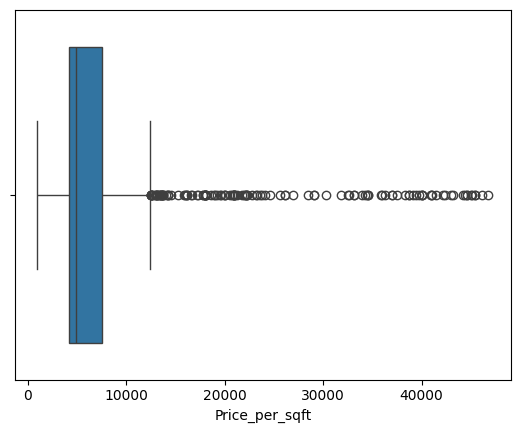

In [ ]:
# sns.boxplot(x=flat_df['Price_per_sqft'])
# plt.show()

In [217]:
log_price=np.log1p(flat_df['Price_per_sqft'])
mean=log_price.mean()
std=log_price.std()
outliers=flat_df[(log_price < mean - 3*std) | (log_price > mean + 3*std)]
print(outliers.shape)
outliers['Price_per_sqft'].describe()

(41, 24)


count       41.000000
mean     38436.243902
std       7295.858568
min        996.000000
25%      35876.000000
50%      39394.000000
75%      42948.000000
max      46763.000000
Name: Price_per_sqft, dtype: float64

In [288]:
# outliers[['Name','Price (INR in Lakhs)','Price_per_sqft','Area_sqft','bedrooms','','is_super_built_up_area','is_built_up_area','is_carpet_area']]

In [213]:
flat_df.drop(index=[849, 954, 1011], inplace=True)

In [216]:
flat_df.loc[1124, 'Area_sqft'] = 672.39
flat_df.loc[1124, 'is_carpet_area'] = True
flat_df.loc[1124, 'is_built_up_area'] = False
flat_df.loc[1124, 'is_super_built_up_area'] = False

In [78]:
oultiers['Price_per_sqft'].describe()

count       39.000000
mean      5735.439509
std       9096.672197
min        996.000000
25%       3440.856663
50%       3716.125196
75%       4118.494761
max      46153.000000
Name: Price_per_sqft, dtype: float64

In [219]:
# Find outlier rows whose area is less than 500
mask = outliers['Area_sqft'] < 500

# Get their indices
idxs = outliers.loc[mask].index

# Convert sqm -> sqft in the main dataframe
flat_df.loc[idxs, 'Area_sqft'] = (
    flat_df.loc[idxs, 'Area_sqft'] * 10.7639
)

# Recalculate price per sqft
flat_df.loc[idxs, 'Price_per_sqft'] = (
    flat_df.loc[idxs, 'Price (INR in Lakhs)'] * 100000
    / flat_df.loc[idxs, 'Area_sqft']
).round()

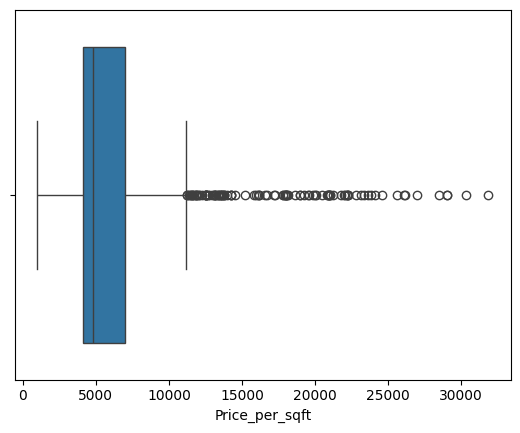

In [220]:
sns.boxplot(x=flat_df['Price_per_sqft'])
plt.show()

In [222]:
log_price=np.log1p(flat_df['Price_per_sqft'])
mean=log_price.mean()
std=log_price.std()
outliers=flat_df[(log_price < mean - 3*std) | (log_price > mean + 3*std)]
outliers.shape

(22, 24)

In [223]:
outliers[['Name','Price (INR in Lakhs)','Price_per_sqft','Area_sqft','bedrooms','Property_URL','is_super_built_up_area','is_built_up_area','is_carpet_area']]

,Name,Price (INR in Lakhs),Price_per_sqft,Area_sqft,bedrooms,Property_URL,is_super_built_up_area,is_built_up_area,is_carpet_area
70,"2 BHK Flatin Gift City, Gandhinagar",140.00,22222.0,1095.000,2.0,https://www.99acres.com/2-bhk-bedroom-apartment-flat-for-sale-in-sobha-dream-heights-gift-city-gandhinagar-1095-sqft-spid-X89338527,True,False,False
112,"2 BHK Flatin Randheja, Gandhinagar",36.00,29032.0,129.168,2.0,https://www.99acres.com/2-bhk-bedroom-apartment-flat-for-sale-in-swamev-sparsh-county-randheja-gandhinagar-124-sqft-spid-S91213322,False,True,False
113,"2 BHK Flatin Randheja, Gandhinagar",36.00,29032.0,124.000,2.0,https://www.99acres.com/2-bhk-bedroom-apartment-flat-for-sale-in-swamev-sparsh-county-randheja-gandhinagar-124-sqft-spid-N91212192,False,True,False
117,"3 BHK Flatin Sargasan, Gandhinagar",125.00,1216.0,10279.620,3.0,https://www.99acres.com/3-bhk-bedroom-apartment-flat-for-sale-in-aavkar-96-sargasan-gandhinagar-10280-sqft-spid-K91150552,False,False,True
185,"1 BHK Flatin Gift City, Gandhinagar",90.00,22222.0,405.000,1.0,https://www.99acres.com/1-bhk-bedroom-apartment-flat-for-sale-in-sobha-avalon-gift-city-gandhinagar-405-sqft-r1-spid-F84164900,False,False,True
224,"2 BHK Flatin Karai, Gandhinagar",44.17,28500.0,155.000,2.0,https://www.99acres.com/2-bhk-bedroom-apartment-flat-for-sale-in-the-rhythm-elevate-karai-gandhinagar-155-sqft-spid-V89573968,False,False,True
305,"3 BHK Flatin Pethapur, Gandhinagar",46.00,23589.0,195.000,3.0,https://www.99acres.com/3-bhk-bedroom-apartment-flat-for-sale-in-rudra-radhika-residency-pethapur-gandhinagar-195-sqft-spid-R86192870,False,False,True
321,"2 BHK Flatin Gift City, Gandhinagar",155.00,24603.0,1109.000,2.0,https://www.99acres.com/2-bhk-bedroom-apartment-flat-for-sale-in-sobha-dream-heights-gift-city-gandhinagar-1109-sq-ft-spid-O83241948,True,False,False
657,"2 BHK Flatin Gift City, Gandhinagar",150.00,23809.0,630.000,2.0,https://www.99acres.com/2-bhk-bedroom-apartment-flat-for-sale-in-sobha-dream-heights-gift-city-gandhinagar-630-sqft-spid-W90864606,False,False,False
808,"1 BHK Flatin Chiloda, Gandhinagar",12.00,26086.0,43.056,1.0,https://www.99acres.com/1-bhk-bedroom-apartment-flat-for-sale-in-chiloda-gandhinagar-46-sqft-spid-S91072330,False,False,True


In [224]:
# Manual corrections
flat_df.loc[117, 'Area_sqft'] = 955

flat_df.loc[657, 'is_carpet_area'] = True
flat_df.loc[657, 'is_built_up_area'] = False
flat_df.loc[657, 'is_super_built_up_area'] = False

flat_df.loc[987, 'Area_sqft'] = 3186.12
flat_df.loc[987, 'is_carpet_area'] = False
flat_df.loc[987, 'is_built_up_area'] = True
flat_df.loc[987, 'is_super_built_up_area'] = False


# Outlier rows having Area_sqft < 400
mask = outliers['Area_sqft'] < 400
idxs = outliers.loc[mask].index

# Convert sqm -> sqft
flat_df.loc[idxs, 'Area_sqft'] = (
    flat_df.loc[idxs, 'Area_sqft'] * 10.7639
)

# Recalculate Price_per_sqft for all outlier rows
flat_df.loc[outliers.index, 'Price_per_sqft'] = (
    flat_df.loc[outliers.index, 'Price (INR in Lakhs)'] * 100000
    / flat_df.loc[outliers.index, 'Area_sqft']
).round()

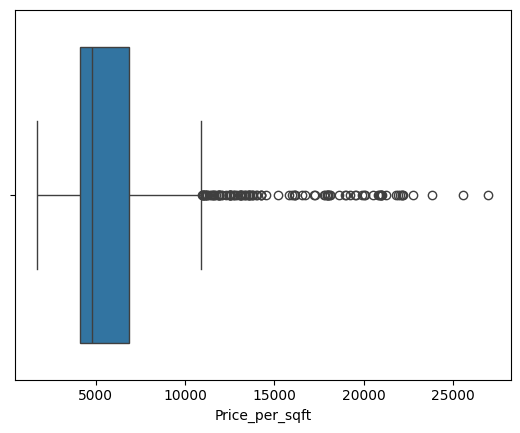

In [225]:
sns.boxplot(x=flat_df['Price_per_sqft'])
plt.show()

In [235]:
log_price=np.log1p(flat_df['Price_per_sqft'])
mean=log_price.mean()
std=log_price.std()
outliers=flat_df[(log_price < mean - 3*std) | (log_price > mean + 3*std)]
print(outliers.shape)
outliers['Price_per_sqft'].describe()

(16, 24)


count       16.000000
mean     22181.000000
std       1870.210184
min      20082.000000
25%      20948.000000
50%      21869.000000
75%      22360.000000
max      26984.000000
Name: Price_per_sqft, dtype: float64

In [236]:
outliers[['Name','Price (INR in Lakhs)','Price_per_sqft','Area_sqft','bedrooms','Property_URL','is_super_built_up_area','is_built_up_area','is_carpet_area']]

,Name,Price (INR in Lakhs),Price_per_sqft,Area_sqft,bedrooms,Property_URL,is_super_built_up_area,is_built_up_area,is_carpet_area
9,"Studio Apartments / 1 RK Flatsin Gift City, Gandhinagar",97.0,20082.0,483.00,1.0,https://www.99acres.com/studio-apartment-flat-for-sale-in-vida-by-nila-spaces-gift-city-gandhinagar-483-sqft-spid-C89513918,False,False,True
185,"1 BHK Flatin Gift City, Gandhinagar",90.0,22222.0,405.00,1.0,https://www.99acres.com/1-bhk-bedroom-apartment-flat-for-sale-in-sobha-avalon-gift-city-gandhinagar-405-sqft-r1-spid-F84164900,False,False,True
208,"3 BHK Flatin Gift City, Gandhinagar",242.0,20508.0,1180.00,3.0,https://www.99acres.com/3-bhk-bedroom-apartment-flat-for-sale-in-vida-by-nila-spaces-gift-city-gandhinagar-1180-sqft-spid-Q89830476,False,False,True
221,"3 BHK Flatin Gift City, Gandhinagar",259.0,21949.0,1180.00,3.0,https://www.99acres.com/3-bhk-bedroom-apartment-flat-for-sale-in-vida-by-nila-spaces-gift-city-gandhinagar-1180-sqft-spid-I89586094,False,False,True
301,"1 BHK Flatin Gift City, Gandhinagar",110.0,20794.0,529.00,1.0,https://www.99acres.com/1-bhk-bedroom-apartment-flat-for-sale-in-vida-by-nila-spaces-gift-city-gandhinagar-529-sqft-spid-A86667154,False,False,True
657,"2 BHK Flatin Gift City, Gandhinagar",150.0,23810.0,630.00,2.0,https://www.99acres.com/2-bhk-bedroom-apartment-flat-for-sale-in-sobha-dream-heights-gift-city-gandhinagar-630-sqft-spid-W90864606,False,False,True
807,"4 BHK Flatin Gift City, Gandhinagar",135.0,20963.0,644.00,4.0,https://www.99acres.com/4-bhk-bedroom-apartment-flat-for-sale-in-gift-city-gandhinagar-644-sqft-spid-V91151430,False,False,True
821,"1 BHK Flatin Gift City, Gandhinagar",111.0,20983.0,529.00,1.0,https://www.99acres.com/1-bhk-bedroom-apartment-flat-for-sale-in-vida-by-nila-spaces-gift-city-gandhinagar-529-sqft-spid-M90792018,False,False,True
893,"Studio Apartments / 1 RK Flatsin Gift City, Gandhinagar",110.0,22774.0,483.00,1.0,https://www.99acres.com/studio-apartment-flat-for-sale-in-vida-by-nila-spaces-gift-city-gandhinagar-483-sqft-spid-T90064230,False,False,True
923,"1 BHK Flatin Gift City, Gandhinagar",95.0,21789.0,436.00,1.0,https://www.99acres.com/1-bhk-bedroom-apartment-flat-for-sale-in-gift-city-gandhinagar-436-sqft-spid-E89814538,False,False,True


In [234]:
flat_df.loc[1247, 'Area_sqft'] = 731.94

# Update Price_per_sqft for ALL rows present in outliers
flat_df.loc[outliers.index, 'Price_per_sqft'] = (
    flat_df.loc[outliers.index, 'Price (INR in Lakhs)'] * 100000
    / flat_df.loc[outliers.index, 'Area_sqft']
).round()

In [241]:
flat_df.loc[321, 'Area_sqft'] = 630
flat_df.loc[321, 'Price_per_sqft'] = (
    flat_df.loc[321, 'Price (INR in Lakhs)'] * 100000
    / flat_df.loc[321, 'Area_sqft']
).round()
flat_df.loc[321, 'is_carpet_area'] = True
flat_df.loc[321, 'is_built_up_area'] = False
flat_df.loc[321, 'is_super_built_up_area'] = False


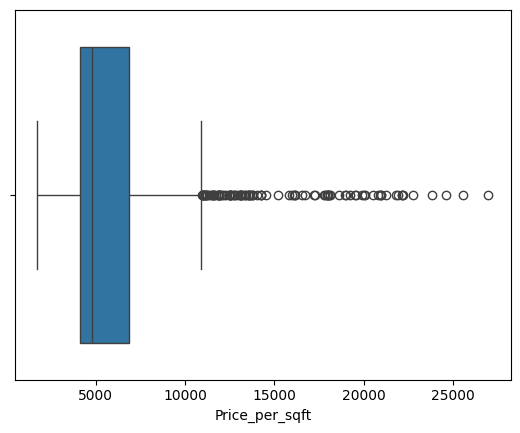

In [242]:
sns.boxplot(x=flat_df['Price_per_sqft'])
plt.show()

In [263]:
flat_df['Price_per_sqft'].describe()

count     1311.000000
mean      6061.321556
std       3472.481362
min       1728.000000
25%       4127.000000
50%       4762.000000
75%       6838.500000
max      26984.000000
Name: Price_per_sqft, dtype: float64

## Area_sqft

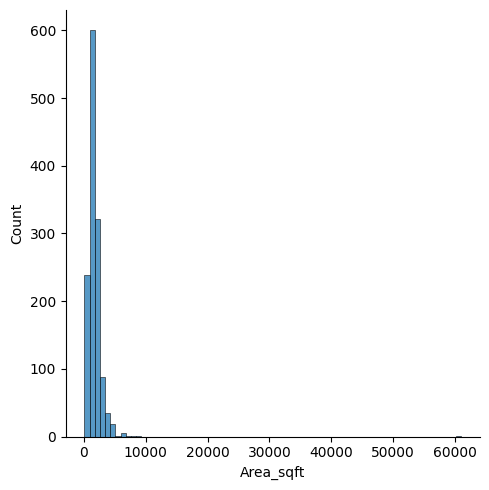

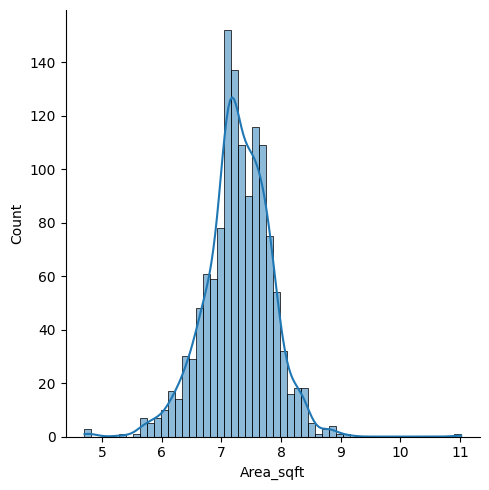

In [ ]:
sns.displot(flat_df['Area_sqft'])
sns.displot(np.log1p(flat_df['Area_sqft']),kde=True)
plt.show()

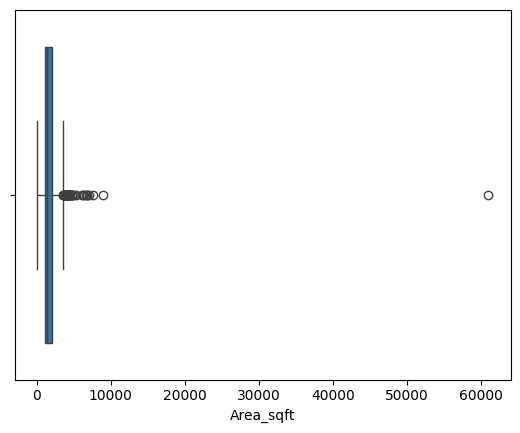

In [247]:
sns.boxplot(x=flat_df['Area_sqft'])
plt.show()

In [250]:
# flat_df[flat_df['Area_sqft']>30000]
flat_df.loc[flat_df['Area_sqft']>30000,'Area_sqft']=706
flat_df.loc[flat_df['Area_sqft']>30000,'Price_per_sqft']=7648.725
flat_df.loc[flat_df['Area_sqft']>30000,'is_carpet_area']=True
flat_df.loc[flat_df['Area_sqft']>30000,'is_super_built_up_area']=False
flat_df.loc[flat_df['Area_sqft']>30000,'is_built_up_area']=False


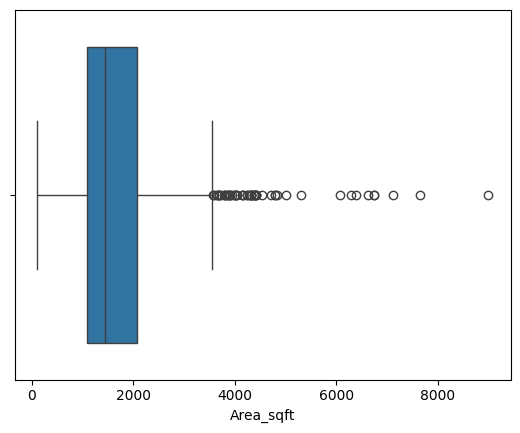

In [251]:
sns.boxplot(x=flat_df['Area_sqft'])
plt.show()

In [254]:
flat_df[flat_df['Area_sqft']>5950][['Name','Price (INR in Lakhs)','Price_per_sqft','Area_sqft','bedrooms','Property_URL','is_super_built_up_area','is_built_up_area','is_carpet_area']]

,Name,Price (INR in Lakhs),Price_per_sqft,Area_sqft,bedrooms,Property_URL,is_super_built_up_area,is_built_up_area,is_carpet_area
140,"6 BHK Flatin Sargasan, Gandhinagar",500.0,5555.0,9000.0,6.0,https://www.99acres.com/6-bhk-bedroom-apartment-flat-for-sale-in-atulyam-the-imperial-sargasan-gandhinagar-9000-sq-ft-spid-F90780200,False,False,True
186,"5 BHK Flatin Koba, Gandhinagar",300.0,4523.0,6633.0,5.0,https://www.99acres.com/5-bhk-bedroom-apartment-flat-for-sale-in-as-asteria-koba-gandhinagar-6633-sq-ft-spid-O90074716,False,False,True
358,"4 BHK Flatin Koba, Gandhinagar",375.0,5556.0,6750.0,4.0,https://www.99acres.com/4-bhk-bedroom-apartment-flat-for-sale-in-ekarth-sarvam-koba-gandhinagar-6750-sqft-r5-spid-L82744274,True,False,False
362,"6 BHK Flatin Khoraj, Gandhinagar",425.0,6996.0,6075.0,6.0,https://www.99acres.com/6-bhk-bedroom-apartment-flat-for-sale-in-khoraj-gandhinagar-6075-sqft-spid-M88951694,True,False,False
363,"6 BHK Flatin Khoraj, Gandhinagar",450.0,7143.0,6300.0,6.0,https://www.99acres.com/6-bhk-bedroom-apartment-flat-for-sale-in-khoraj-gandhinagar-6300-sqft-spid-M88951534,True,False,False
395,"4 BHK Flatin Koba, Gandhinagar",425.0,5556.0,7650.0,4.0,https://www.99acres.com/4-bhk-bedroom-apartment-flat-for-sale-in-ekarth-sarvam-koba-gandhinagar-7650-sqft-r2-spid-E82744814,True,False,False
487,"4 BHK Flatin Raysan, Gandhinagar",357.0,5289.0,6750.0,4.0,https://www.99acres.com/4-bhk-bedroom-apartment-flat-for-sale-in-raysan-gandhinagar-6750-sqft-r4-spid-Y85650918,True,False,False
698,"5 BHK Flatin Kudasan, Gandhinagar",300.0,4209.0,7128.0,5.0,https://www.99acres.com/5-bhk-bedroom-apartment-flat-for-sale-in-kudasan-gandhinagar-7128-sqft-spid-W89797098,False,False,True
1229,"5 BHK Flatin Raysan, Gandhinagar",300.0,4688.0,6399.0,5.0,https://www.99acres.com/5-bhk-bedroom-apartment-flat-for-sale-in-raysan-gandhinagar-6399-sqft-spid-E86501958,False,False,True


In [257]:
flat_df.drop(index=698, inplace=True)

i verify all value of area_sqft on 99 acres and other sites it founded geniue and so these point are not outliers but they are correct and we can not drop them.







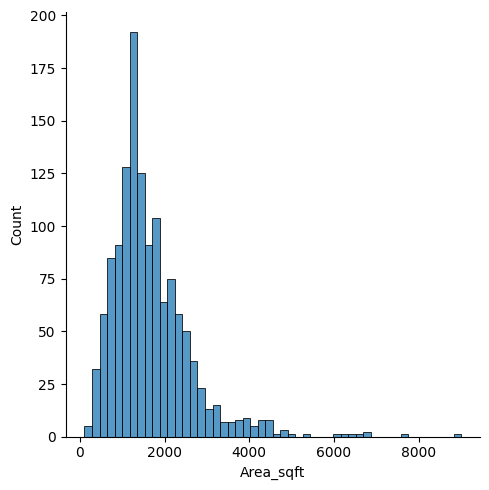

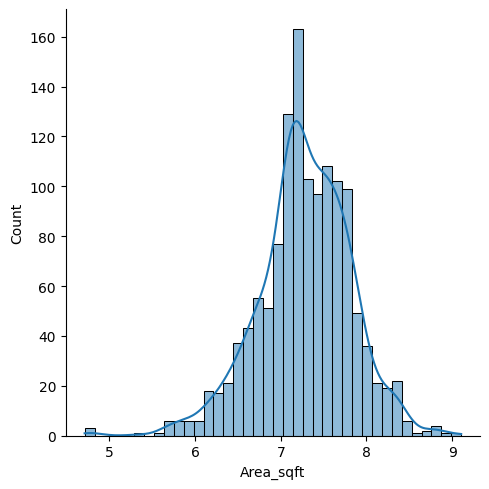

In [260]:
# sns.boxplot(x=flat_df['Area_sqft'])
sns.displot(flat_df['Area_sqft'])
sns.displot(np.log1p(flat_df['Area_sqft']),kde=True)
plt.show()

In [261]:
log_area=np.log1p(flat_df['Area_sqft'])
mean=log_area.mean()
std=log_area.std()
outliers=flat_df[(log_area < mean - 3*std) | (log_area > mean + 3*std)]
print(outliers.shape)
outliers['Area_sqft'].describe()

(7, 24)


count       7.000000
mean     2497.428571
std      4000.434095
min       110.000000
25%       121.000000
50%       210.000000
75%      3960.000000
max      9000.000000
Name: Area_sqft, dtype: float64

In [262]:
outliers[['Name','Price (INR in Lakhs)','Price_per_sqft','Area_sqft','bedrooms','Property_URL','is_super_built_up_area','is_built_up_area','is_carpet_area']]

,Name,Price (INR in Lakhs),Price_per_sqft,Area_sqft,bedrooms,Property_URL,is_super_built_up_area,is_built_up_area,is_carpet_area
104,"2 BHK Flatin GIDC, Dahegam, Gandhinagar",15.5,12916.0,120.0,2.0,https://www.99acres.com/2-bhk-bedroom-apartment-flat-for-sale-in-gidc-gandhinagar-120-sqft-spid-M91309902,False,False,True
140,"6 BHK Flatin Sargasan, Gandhinagar",500.0,5555.0,9000.0,6.0,https://www.99acres.com/6-bhk-bedroom-apartment-flat-for-sale-in-atulyam-the-imperial-sargasan-gandhinagar-9000-sq-ft-spid-F90780200,False,False,True
395,"4 BHK Flatin Koba, Gandhinagar",425.0,5556.0,7650.0,4.0,https://www.99acres.com/4-bhk-bedroom-apartment-flat-for-sale-in-ekarth-sarvam-koba-gandhinagar-7650-sqft-r2-spid-E82744814,True,False,False
1136,"Studio Apartments / 1 RK Flatsin Sector 24, Gandhinagar",15.0,7143.0,210.0,1.0,https://www.99acres.com/studio-apartment-flat-for-sale-in-sector-24-gandhinagar-210-sqft-spid-O87809336,False,False,True
1182,"2 BHK Flatin Dahegam, Gandhinagar",16.0,14545.0,110.0,2.0,https://www.99acres.com/2-bhk-bedroom-apartment-flat-for-sale-in-dhegam-gandhinagar-110-sqft-spid-J87360938,False,False,True
1239,"1 BHK Flatin Randheja, Gandhinagar",25.0,9259.0,270.0,1.0,https://www.99acres.com/1-bhk-bedroom-apartment-flat-for-sale-in-randheja-gandhinagar-270-sqft-spid-X86418606,False,False,False
1295,"1 BHK Flatin Kalol, Gandhinagar",21.0,17213.0,122.0,2.0,https://www.99acres.com/1-bhk-bedroom-apartment-flat-for-sale-in-maruti-shyam-heights-kalol-gandhinagar-122-sqft-spid-X85588738,False,False,True


In [264]:
flat_df=flat_df.drop(index=[1295,104,1182])

## bedrooms

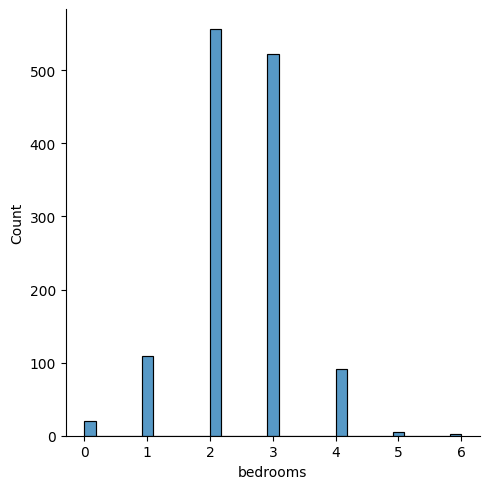

In [267]:
sns.displot(flat_df['bedrooms'])
plt.show()

In [ ]:
flat_df[flat_df['bedrooms']==0][['Name','Price (INR in Lakhs)','Price_per_sqft','Area_sqft','bedrooms','Property_URL','is_super_built_up_area','is_built_up_area','is_carpet_area']]

,Name,Price (INR in Lakhs),Price_per_sqft,Area_sqft,bedrooms,Property_URL,is_super_built_up_area,is_built_up_area,is_carpet_area
12,"2 BHK Flatin Raysan, Gandhinagar",59.0,4149.000000,1422.00,0.0,https://www.99acres.com/2-bhk-bedroom-apartment-flat-for-sale-in-sre-luvkush-4-raysan-gandhinagar-1422-sqft-spid-V88148666,True,False,False
144,"2 BHK Flatin Sargasan, Gandhinagar",58.0,5625.879044,1030.95,0.0,https://www.99acres.com/2-bhk-bedroom-apartment-flat-for-sale-in-swagat-flamingo-sargasan-gandhinagar-11097-sqft-spid-N90738336,False,False,True
188,"3 BHK Flatin Sargasan, Gandhinagar",78.0,4814.000000,1620.00,0.0,https://www.99acres.com/3-bhk-bedroom-apartment-flat-for-sale-in-atishay-sky-sargasan-gandhinagar-1620-sq-ft-spid-L90044428,False,False,True
243,"2 BHK Flatin Sargasan, Gandhinagar",53.0,4427.000000,1197.00,0.0,https://www.99acres.com/2-bhk-bedroom-apartment-flat-for-sale-in-swagat-afford-sargasan-gandhinagar-1197-sqft-spid-B88918210,False,True,False
265,"2 BHK Flatin Kalol, Gandhinagar",45.0,3846.000000,1170.00,0.0,https://www.99acres.com/2-bhk-bedroom-apartment-flat-for-sale-in-parshwanath-royal-residency-kalol-gandhinagar-1170-sq-ft-r5-spid-N52787868,True,False,False
285,"3 BHK Flatin Sargasan, Gandhinagar",93.0,4408.000000,2109.00,0.0,https://www.99acres.com/3-bhk-bedroom-apartment-flat-for-sale-in-atishay-shivalay-3-sargasan-gandhinagar-2110-sqft-spid-C87581246,False,False,True
1030,"Studio Apartments / 1 RK Flatsin Kalol, Gandhinagar",11.5,2719.000000,423.00,0.0,https://www.99acres.com/studio-apartment-flat-for-sale-in-tata-shubh-griha-kalol-gandhinagar-423-sqft-spid-V88724330,True,False,False
1059,"2 BHK Flatin Sargasan, Gandhinagar",85.0,10866.000000,782.25,0.0,https://www.99acres.com/2-bhk-bedroom-apartment-flat-for-sale-in-swagat-kingsland-sargasan-gandhinagar-782-sqft-spid-V88466590,False,False,True
1069,"2 BHK Flatin Vavol, Gandhinagar",50.0,4425.000000,1130.00,0.0,https://www.99acres.com/2-bhk-bedroom-apartment-flat-for-sale-in-anasya-greenz-vavol-gandhinagar-1130-sqft-r1-spid-D81705918,False,False,True
1098,"Studio Apartments / 1 RK Flatsin Kalol, Gandhinagar",12.0,2051.000000,585.00,0.0,https://www.99acres.com/studio-apartment-flat-for-sale-in-tata-shubh-griha-kalol-gandhinagar-585-sqft-spid-U88156658,False,False,True


In [275]:
flat_df['Bedrooms'] = np.where(
    flat_df['Name'].str.contains('Studio|1 RK', case=False, na=False),
    1,
    flat_df['Name'].str.extract(r'(\d+)\s*BHK', expand=False).astype(float)
)

In [278]:
flat_df[flat_df['Bedrooms'].isnull()]

,Name,Location,Price (INR in Lakhs),Price_per_sqft,Area_sqft,Description,Property_URL,bedrooms,bathrooms,balconies,...,property_age_bucket,is_ready_to_move,is_built_up_area,is_carpet_area,is_super_built_up_area,property_type,luxury_score,location_advantage_score,log_price,Bedrooms
815,"2 Bedroom Farm housein Khatraj, Gandhinagar","Khatraj, Gandhinagar",180.0,5682.0,3168.00,"We are the proud owners of this 2 bhk apartment available in , khatraj, gandhinagar. This , priced approximately at rs1.8 crore. It will be ready for possession within 6 months. It is a resale and an under construction apartment. The unit is located on null floor and has . It has 2 bathroom(s). The ownership is freehold type.",https://www.99acres.com/2-bhk-bedroom-farm-house-for-sale-in-arvind-forreste-5-khatraj-ahmedabad-south-3168-sqft-spid-C90899416,2.0,2.0,1.0,...,New,0,False,False,False,apartment,0.0,0.0,5.198497,NaN
987,"4 Bedroom Housein Sector 4D Gandhinagar, Sector 4 Gandhinagar","Sector 4D Gandhinagar, Sector 4 Gandhinagar",380.0,11927.0,3186.12,Selling my apartment Title clear 135m plot Full furnished New construction,https://www.99acres.com/4-bhk-bedroom-independent-house-villa-for-sale-in-sector-4d-gandhinagar-3186-sqft-spid-V89296539,4.0,4.0,2.0,...,New,1,True,False,False,apartment,0.0,0.0,5.942799,NaN
1209,"Residential propertyin Sargasan, Gandhinagar","Sargasan, Gandhinagar",16.0,4326.0,369.85,I have 1 bhk flat in sargasan erea. I want sell my flat on power of attorney,https://www.99acres.com/other-residential-property-for-sale-in-sargasan-gandhinagar-370-sqft-spid-L86883922,NaN,NaN,NaN,...,Unknown,1,False,False,False,apartment,0.0,0.0,2.833213,NaN
1315,"Residential propertyin Vavol, Gandhinagar","Vavol, Gandhinagar",32.0,3200.0,1000.00,NaN,https://www.99acres.com/other-residential-property-for-sale-in-vavol-gandhinagar-1000-sqft-spid-Y83883628,NaN,NaN,NaN,...,Unknown,1,False,False,False,apartment,NaN,NaN,3.496508,NaN


In [279]:
flat_df.loc[1209,'Bedrooms']=1

In [280]:
# Append rows to house_df
house_df = pd.concat([house_df, flat_df.loc[[815, 987]]])

# Remove rows from flat_df
flat_df = flat_df.drop(index=[815, 987])

In [281]:
print(815 in flat_df.index, 987 in flat_df.index)
print(815 in house_df.index, 987 in house_df.index)

False False
True True


In [284]:
flat_df.loc[1315,'Bedrooms']=2

In [289]:
flat_df[flat_df['bedrooms']!=flat_df['Bedrooms']][['Name','Price (INR in Lakhs)','Price_per_sqft','Area_sqft','bedrooms','Bedrooms','is_super_built_up_area','is_built_up_area','is_carpet_area']]

,Name,Price (INR in Lakhs),Price_per_sqft,Area_sqft,bedrooms,Bedrooms,is_super_built_up_area,is_built_up_area,is_carpet_area
12,"2 BHK Flatin Raysan, Gandhinagar",59.0,4149.000000,1422.0000,0.0,2.0,True,False,False
19,"3 BHK Flatin Gift City, Gandhinagar",95.0,4549.000000,2088.0000,2.0,3.0,True,False,False
40,"3 BHK Flatin Kudasan, Gandhinagar",85.0,4794.000000,1773.0000,2.0,3.0,True,False,False
114,"3 BHK Flatin Uvarsad, Gandhinagar",90.0,4878.000000,1845.0000,2.0,3.0,False,False,True
144,"2 BHK Flatin Sargasan, Gandhinagar",58.0,5625.879044,1030.9500,0.0,2.0,False,False,True
188,"3 BHK Flatin Sargasan, Gandhinagar",78.0,4814.000000,1620.0000,0.0,3.0,False,False,True
243,"2 BHK Flatin Sargasan, Gandhinagar",53.0,4427.000000,1197.0000,0.0,2.0,False,True,False
250,"3 BHK Flatin Randesan, Gandhinagar",115.0,4768.000000,2412.0000,2.0,3.0,False,False,True
252,"2 BHK Flatin Gift City, Gandhinagar",166.0,11000.000000,1511.0000,3.0,2.0,False,False,True
265,"2 BHK Flatin Kalol, Gandhinagar",45.0,3846.000000,1170.0000,0.0,2.0,True,False,False


In [299]:
flat_df[flat_df['Bedrooms']<flat_df['bathrooms']][['Name','Price (INR in Lakhs)','Price_per_sqft','Area_sqft','Bedrooms','bathrooms','balconies','Property_URL','is_super_built_up_area','is_built_up_area','is_carpet_area']]

,Name,Price (INR in Lakhs),Price_per_sqft,Area_sqft,Bedrooms,bathrooms,balconies,Property_URL,is_super_built_up_area,is_built_up_area,is_carpet_area
52,"4 BHK Flatin Sargasan, Gandhinagar",325.00,11607.0,2800.000,4.0,6.0,1.0,https://www.99acres.com/4-bhk-bedroom-apartment-flat-for-sale-in-siddhraj-z-plus-sargasan-gandhinagar-2800-sqft-spid-D89554432,False,False,True
136,"1 BHK Flatin Vavol, Gandhinagar",35.50,5916.0,600.000,1.0,2.0,1.0,https://www.99acres.com/1-bhk-bedroom-apartment-flat-for-sale-in-jayde-arjun-226-vavol-gandhinagar-600-sq-ft-spid-Q90783504,False,False,True
147,"2 BHK Flatin Kudasan, Gandhinagar",90.00,5997.0,1584.000,2.0,3.0,1.0,https://www.99acres.com/2-bhk-bedroom-apartment-flat-for-sale-in-kudasan-gandhinagar-1584-sqft-spid-S90650276,True,False,False
152,"1 BHK Flatin Vavol, Gandhinagar",32.00,3865.0,828.000,1.0,2.0,2.0,https://www.99acres.com/1-bhk-bedroom-apartment-flat-for-sale-in-jayde-arjun-226-vavol-gandhinagar-828-sqft-spid-N90519398,False,False,True
170,"1 BHK Flatin adalaj, Gandhinagar",26.00,3019.0,861.112,1.0,2.0,1.0,https://www.99acres.com/1-bhk-bedroom-apartment-flat-for-sale-in-gandhinagar-80-sqft-spid-R90315462,False,False,True
181,"1 BHK Flatin Vavol, Gandhinagar",35.50,4551.0,780.000,1.0,2.0,1.0,https://www.99acres.com/1-bhk-bedroom-apartment-flat-for-sale-in-jayde-arjun-226-vavol-gandhinagar-780-sqft-spid-B90231324,False,False,True
252,"2 BHK Flatin Gift City, Gandhinagar",166.00,11000.0,1511.000,2.0,3.0,2.0,https://www.99acres.com/2-bhk-bedroom-apartment-flat-for-sale-in-shilp-north-sky-gift-city-gandhinagar-1511-sqft-spid-T88867484,False,False,True
276,"3 BHK Flatin Kudasan, Gandhinagar",145.00,4489.0,3230.000,3.0,4.0,3.0,https://www.99acres.com/3-bhk-bedroom-apartment-flat-for-sale-in-shivalay-parisar-kudasan-gandhinagar-3230-sqft-spid-C88372154,True,False,False
291,"3 BHK Flatin adalaj, Gandhinagar",100.00,8818.0,1134.000,3.0,4.0,3.0,https://www.99acres.com/3-bhk-bedroom-apartment-flat-for-sale-in-gandhinagar-1134-sqft-spid-R87335048,False,False,True
316,"4 BHK Flatin Sargasan, Gandhinagar",365.00,9259.0,3942.000,4.0,6.0,1.0,https://www.99acres.com/4-bhk-bedroom-apartment-flat-for-sale-in-siddhraj-z-plus-sargasan-gandhinagar-3942-sqft-spid-I84205158,True,False,False


In [301]:
mask1 = {
    52:  (5, 3),
    170: (2, 2),
    181: (2, 3),
    252: (2, 1),
    291: (3, 2),
    386: (3, 3),
    637: (1, 1),
    915: (2, 0),
    956: (1, 1),
    966: (1, 1),
    999: (2, 0),
    1049: (4, 1),
    1052: (1, 1),
    1143: (3, 2),
    1179: (2, 3)
}

for idx, (bathrooms, balconies) in mask1.items():
    flat_df.loc[idx, 'bathrooms'] = bathrooms
    flat_df.loc[idx, 'balconies'] = balconies

In [302]:
processed_idx = list(mask1.keys())

flat_df[
    (flat_df['Bedrooms'] < flat_df['balconies']) &
    (~flat_df.index.isin(processed_idx))
][['Name','Price (INR in Lakhs)','Price_per_sqft','Area_sqft','Bedrooms','bathrooms','balconies','Property_URL','is_super_built_up_area','is_built_up_area','is_carpet_area']]

,Name,Price (INR in Lakhs),Price_per_sqft,Area_sqft,Bedrooms,bathrooms,balconies,Property_URL,is_super_built_up_area,is_built_up_area,is_carpet_area
13,"2 BHK Flatin Vavol, Gandhinagar",60.50,5465.0,1107.0000,2.0,2.0,3.0,https://www.99acres.com/2-bhk-bedroom-apartment-flat-for-sale-in-radhe-vrundavan-residency-vavol-gandhinagar-1107-sqft-r2-spid-L76565921,False,False,True
61,"2 BHK Flatin Vavol, Gandhinagar",49.50,4471.0,1107.0000,2.0,2.0,3.0,https://www.99acres.com/2-bhk-bedroom-apartment-flat-for-sale-in-radhe-vrundavan-residency-vavol-gandhinagar-1107-sqft-r2-spid-L76565921,False,False,True
125,"2 BHK Flatin Sargasan, Gandhinagar",75.00,5446.0,1377.0000,2.0,2.0,3.0,https://www.99acres.com/2-bhk-bedroom-apartment-flat-for-sale-in-devnandan-summit-sargasan-gandhinagar-1377-sqft-spid-K90993824,True,False,False
141,"1 BHK Flatin Koba, Gandhinagar",33.50,4618.0,747.0000,1.0,1.0,2.0,https://www.99acres.com/1-bhk-bedroom-apartment-flat-for-sale-in-satyamev-surya-koba-gandhinagar-747-sqft-spid-C90765230,True,False,False
146,"2 BHK Flatin Sargasan, Gandhinagar",55.00,3917.0,1404.0000,2.0,2.0,3.0,https://www.99acres.com/2-bhk-bedroom-apartment-flat-for-sale-in-b-and-m-divya-sanskar-city-sargasan-gandhinagar-1404-sqft-spid-S90671916,False,True,False
152,"1 BHK Flatin Vavol, Gandhinagar",32.00,3865.0,828.0000,1.0,2.0,2.0,https://www.99acres.com/1-bhk-bedroom-apartment-flat-for-sale-in-jayde-arjun-226-vavol-gandhinagar-828-sqft-spid-N90519398,False,False,True
187,"2 BHK Flatin Sardar Patel Ring Road, Gandhinagar",59.00,4736.0,1140.0000,2.0,2.0,3.0,https://www.99acres.com/2-bhk-bedroom-apartment-flat-for-sale-in-sardar-patel-ring-road-gandhinagar-1140-sq-ft-r1-spid-E82591990,False,True,False
190,"2 BHK Flatin Gift City, Gandhinagar",163.00,12439.0,1307.0000,2.0,2.0,3.0,https://www.99acres.com/2-bhk-bedroom-apartment-flat-for-sale-in-sobha-avalon-gift-city-gandhinagar-1308-sqft-spid-C90007434,True,False,False
191,"3 BHK Flatin Chiloda, Gandhinagar",75.00,7653.0,980.0000,3.0,3.0,4.0,https://www.99acres.com/3-bhk-bedroom-apartment-flat-for-sale-in-sai-flora-chiloda-gandhinagar-980-sqft-spid-C90004796,False,False,False
204,"2 BHK Flatin Sargasan, Gandhinagar",45.00,6455.0,697.0000,2.0,2.0,3.0,https://www.99acres.com/2-bhk-bedroom-apartment-flat-for-sale-in-b-and-m-divya-sanskar-city-sargasan-gandhinagar-697-sqft-spid-W89865682,False,True,False


In [ ]:
flat_df.loc[1041,'balconies']=4



In [304]:
flat_df[flat_df['bathrooms'].isnull()]

,Name,Location,Price (INR in Lakhs),Price_per_sqft,Area_sqft,Description,Property_URL,bedrooms,bathrooms,balconies,...,is_built_up_area,is_carpet_area,is_super_built_up_area,property_type,luxury_score,location_advantage_score,log_price,Bedrooms,Bathrooms,Balconies
1209,"Residential propertyin Sargasan, Gandhinagar","Sargasan, Gandhinagar",16.0,4326.0,369.85,I have 1 bhk flat in sargasan erea. I want sell my flat on power of attorney,https://www.99acres.com/other-residential-property-for-sale-in-sargasan-gandhinagar-370-sqft-spid-L86883922,NaN,NaN,NaN,...,False,False,False,apartment,0.0,0.0,2.833213,1.0,NaN,NaN
1315,"Residential propertyin Vavol, Gandhinagar","Vavol, Gandhinagar",32.0,3200.0,1000.00,NaN,https://www.99acres.com/other-residential-property-for-sale-in-vavol-gandhinagar-1000-sqft-spid-Y83883628,NaN,NaN,NaN,...,False,False,False,apartment,NaN,NaN,3.496508,2.0,NaN,NaN


In [ ]:
flat_df.loc[1209,'bathrooms']=1
flat_df.loc[1209,'balconies']=0

flat_df.loc[1315,'bathrooms']=1
flat_df.loc[1315,'balconies']=1

In [310]:
flat_df['bathrooms'].value_counts()

bathrooms
2.0    578
3.0    491
1.0    127
4.0     87
5.0     13
0.0      5
6.0      5
Name: count, dtype: int64

In [311]:
flat_df[flat_df['bathrooms']==0][['Name','Price (INR in Lakhs)','Price_per_sqft','Area_sqft','Bedrooms','bathrooms','balconies','Property_URL','is_super_built_up_area','is_built_up_area','is_carpet_area']]

,Name,Price (INR in Lakhs),Price_per_sqft,Area_sqft,Bedrooms,bathrooms,balconies,Property_URL,is_super_built_up_area,is_built_up_area,is_carpet_area
12,"2 BHK Flatin Raysan, Gandhinagar",59.0,4149.0,1422.00,2.0,0.0,0.0,https://www.99acres.com/2-bhk-bedroom-apartment-flat-for-sale-in-sre-luvkush-4-raysan-gandhinagar-1422-sqft-spid-V88148666,True,False,False
188,"3 BHK Flatin Sargasan, Gandhinagar",78.0,4814.0,1620.00,3.0,0.0,0.0,https://www.99acres.com/3-bhk-bedroom-apartment-flat-for-sale-in-atishay-sky-sargasan-gandhinagar-1620-sq-ft-spid-L90044428,False,False,True
1124,"3 BHK Flatin Randheja, Gandhinagar",69.0,10262.0,672.39,3.0,0.0,0.0,https://www.99acres.com/3-bhk-bedroom-apartment-flat-for-sale-in-polaris-elina-randheja-gandhinagar-6930-sqft-spid-U87884776,False,False,True
1188,"2 BHK Flatin Randesan, Gandhinagar",50.0,4085.0,1224.00,2.0,0.0,0.0,https://www.99acres.com/2-bhk-bedroom-apartment-flat-for-sale-in-ganesh-kesar-aangan-randesan-gandhinagar-1224-sqft-spid-R86245382,False,False,True
1221,"3 BHK Flatin Sargasan, Gandhinagar",82.0,9599.0,854.22,3.0,0.0,0.0,https://www.99acres.com/3-bhk-bedroom-apartment-flat-for-sale-in-shreeji-woods-ville-sargasan-gandhinagar-2164-sqft-spid-P86675954,False,False,True


In [313]:
# flat_df.loc[12, ['bathrooms', 'balconies']] = [2, 1]
flat_df.loc[188, ['bathrooms', 'balconies']] = [2, 3]
flat_df.loc[1124, ['bathrooms', 'balconies']] = [3, 2]
flat_df.loc[1188, ['bathrooms', 'balconies']] = [2, 2]
flat_df.loc[1221, ['bathrooms', 'balconies']] = [3, 1]

In [316]:
flat_df[flat_df['balconies']==0][['Name','Price (INR in Lakhs)','Price_per_sqft','Area_sqft','Bedrooms','bathrooms','balconies','Property_URL','is_super_built_up_area','is_built_up_area','is_carpet_area']]

,Name,Price (INR in Lakhs),Price_per_sqft,Area_sqft,Bedrooms,bathrooms,balconies,Property_URL,is_super_built_up_area,is_built_up_area,is_carpet_area
144,"2 BHK Flatin Sargasan, Gandhinagar",58.00,5625.879044,1030.95,2.0,1.0,0.0,https://www.99acres.com/2-bhk-bedroom-apartment-flat-for-sale-in-swagat-flamingo-sargasan-gandhinagar-11097-sqft-spid-N90738336,False,False,True
243,"2 BHK Flatin Sargasan, Gandhinagar",53.00,4427.000000,1197.00,2.0,1.0,0.0,https://www.99acres.com/2-bhk-bedroom-apartment-flat-for-sale-in-swagat-afford-sargasan-gandhinagar-1197-sqft-spid-B88918210,False,True,False
265,"2 BHK Flatin Kalol, Gandhinagar",45.00,3846.000000,1170.00,2.0,1.0,0.0,https://www.99acres.com/2-bhk-bedroom-apartment-flat-for-sale-in-parshwanath-royal-residency-kalol-gandhinagar-1170-sq-ft-r5-spid-N52787868,True,False,False
285,"3 BHK Flatin Sargasan, Gandhinagar",93.00,4408.000000,2109.00,3.0,1.0,0.0,https://www.99acres.com/3-bhk-bedroom-apartment-flat-for-sale-in-atishay-shivalay-3-sargasan-gandhinagar-2110-sqft-spid-C87581246,False,False,True
915,"1 BHK Flatin Sargasan, Gandhinagar",40.00,5714.000000,700.00,1.0,2.0,0.0,https://www.99acres.com/1-bhk-bedroom-apartment-flat-for-sale-in-kalp-capitol-flora-sargasan-gandhinagar-700-sqft-spid-F89870488,False,False,True
999,"1 BHK Flatin Sargasan, Gandhinagar",37.51,4709.000000,796.53,1.0,2.0,0.0,https://www.99acres.com/1-bhk-bedroom-apartment-flat-for-sale-in-sargasan-gandhinagar-797-sqft-spid-T89076860,False,False,False
1059,"2 BHK Flatin Sargasan, Gandhinagar",85.00,10866.000000,782.25,2.0,1.0,0.0,https://www.99acres.com/2-bhk-bedroom-apartment-flat-for-sale-in-swagat-kingsland-sargasan-gandhinagar-782-sqft-spid-V88466590,False,False,True
1098,"Studio Apartments / 1 RK Flatsin Kalol, Gandhinagar",12.00,2051.000000,585.00,1.0,1.0,0.0,https://www.99acres.com/studio-apartment-flat-for-sale-in-tata-shubh-griha-kalol-gandhinagar-585-sqft-spid-U88156658,False,False,True
1130,"2 BHK Flatin Sargasan, Gandhinagar",75.00,5447.000000,1377.00,2.0,1.0,0.0,https://www.99acres.com/2-bhk-bedroom-apartment-flat-for-sale-in-devnandan-summit-sargasan-gandhinagar-1377-sqft-spid-O87844162,True,False,False
1161,"3 BHK Flatin Vavol, Gandhinagar",62.00,8058.000000,769.40,3.0,1.0,0.0,https://www.99acres.com/3-bhk-bedroom-apartment-flat-for-sale-in-neelkanth-jay-visat-mangalya-vavol-gandhinagar-769-sqft-spid-D87651004,False,False,True


In [318]:
# flat_df.loc[144, ['bathrooms', 'balconies']] = [2, 3]
# flat_df.loc[243, ['bathrooms', 'balconies']] = [2,1]
# flat_df.loc[265, ['bathrooms', 'balconies']] = [2,3]
# flat_df.loc[285, ['bathrooms', 'balconies']] = [3,2]
# flat_df.loc[1059, ['bathrooms', 'balconies']] = [2, 2]
# flat_df.loc[1130, ['bathrooms', 'balconies']] = [2, 3]
# flat_df.loc[1161, ['bathrooms', 'balconies']] = [3, 2]

In [319]:
flat_df.loc[1059,['Price (INR in Lakhs)']]=78
flat_df.loc[1059,['Price_per_sqft']]=9971.23

In [324]:
mask=flat_df[
    (abs(flat_df['Bedrooms'] - flat_df['bathrooms']) > 2) |
    (abs(flat_df['Bedrooms'] - flat_df['balconies']) > 2) |
    (abs(flat_df['bathrooms'] - flat_df['balconies']) > 2)
][['Name','Price (INR in Lakhs)','Price_per_sqft','Area_sqft','Bedrooms','bathrooms','balconies','Property_URL','is_super_built_up_area','is_built_up_area','is_carpet_area']]
mask

,Name,Price (INR in Lakhs),Price_per_sqft,Area_sqft,Bedrooms,bathrooms,balconies,Property_URL,is_super_built_up_area,is_built_up_area,is_carpet_area
300,"5 BHK Flatin Randesan, Gandhinagar",180.0,4237.0,4248.0000,5.0,3.0,2.0,https://www.99acres.com/5-bhk-bedroom-apartment-flat-for-sale-in-royal-riviera-2-randesan-gandhinagar-4248-sqft-spid-O86671034,False,False,True
316,"4 BHK Flatin Sargasan, Gandhinagar",365.0,9259.0,3942.0000,4.0,6.0,1.0,https://www.99acres.com/4-bhk-bedroom-apartment-flat-for-sale-in-siddhraj-z-plus-sargasan-gandhinagar-3942-sqft-spid-I84205158,True,False,False
358,"4 BHK Flatin Koba, Gandhinagar",375.0,5556.0,6750.0000,4.0,4.0,1.0,https://www.99acres.com/4-bhk-bedroom-apartment-flat-for-sale-in-ekarth-sarvam-koba-gandhinagar-6750-sqft-r5-spid-L82744274,True,False,False
359,"4 BHK Flatin Khoraj, Gandhinagar",230.0,6310.0,3645.0000,4.0,4.0,1.0,https://www.99acres.com/4-bhk-bedroom-apartment-flat-for-sale-in-khoraj-gandhinagar-3645-sqft-r1-spid-B88951100,True,False,False
362,"6 BHK Flatin Khoraj, Gandhinagar",425.0,6996.0,6075.0000,6.0,6.0,1.0,https://www.99acres.com/6-bhk-bedroom-apartment-flat-for-sale-in-khoraj-gandhinagar-6075-sqft-spid-M88951694,True,False,False
363,"6 BHK Flatin Khoraj, Gandhinagar",450.0,7143.0,6300.0000,6.0,6.0,1.0,https://www.99acres.com/6-bhk-bedroom-apartment-flat-for-sale-in-khoraj-gandhinagar-6300-sqft-spid-M88951534,True,False,False
364,"4 BHK Flatin Khoraj, Gandhinagar",250.0,6567.0,3807.0000,4.0,4.0,1.0,https://www.99acres.com/4-bhk-bedroom-apartment-flat-for-sale-in-khoraj-gandhinagar-3807-sqft-spid-E88951288,True,False,False
365,"4 BHK Flatin Khoraj, Gandhinagar",240.0,6488.0,3699.0000,4.0,4.0,1.0,https://www.99acres.com/4-bhk-bedroom-apartment-flat-for-sale-in-khoraj-gandhinagar-3699-sqft-spid-V88951182,True,False,False
366,"4 BHK Flatin Khoraj, Gandhinagar",220.0,6220.0,3537.0000,4.0,4.0,1.0,https://www.99acres.com/4-bhk-bedroom-apartment-flat-for-sale-in-khoraj-gandhinagar-3537-sqft-spid-F88951012,True,False,False
376,"4 BHK Flatin Randesan, Gandhinagar",130.0,4377.0,2970.0000,4.0,4.0,1.0,https://www.99acres.com/4-bhk-bedroom-apartment-flat-for-sale-in-keshav-elitus-randesan-gandhinagar-2970-sqft-spid-D89566786,True,False,False


In [ ]:
flat_df.loc[140, ['bathrooms', 'balconies']] = [5, 4]
flat_df.loc[186, ['bathrooms', 'balconies']] = [3, 3]
flat_df.loc[300, ['bathrooms', 'balconies']] = [3, 2]
flat_df.loc[344, ['bathrooms', 'balconies']] = [4, 3]
flat_df.loc[439, ['bathrooms', 'balconies']] = [4, 1]

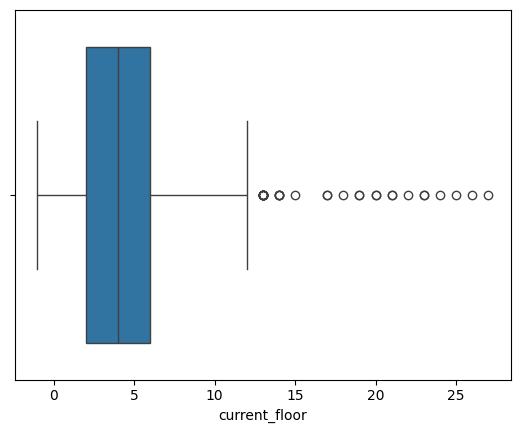

In [332]:
# sns.displot(flat_df['current_floor'])

sns.boxplot(x=flat_df['current_floor'])
plt.show()


In [338]:
mask=flat_df[flat_df['current_floor']>=12]
mask[['Name','current_floor','total_floors','Property_URL','is_super_built_up_area','is_built_up_area','is_carpet_area']]

,Name,current_floor,total_floors,Property_URL,is_super_built_up_area,is_built_up_area,is_carpet_area
9,"Studio Apartments / 1 RK Flatsin Gift City, Gandhinagar",27.0,NaN,https://www.99acres.com/studio-apartment-flat-for-sale-in-vida-by-nila-spaces-gift-city-gandhinagar-483-sqft-spid-C89513918,False,False,True
14,"4 BHK Flatin Koba, Gandhinagar",12.0,NaN,https://www.99acres.com/4-bhk-bedroom-apartment-flat-for-sale-in-maruti-skyra-koba-gandhinagar-3870-sqft-spid-T88688802,True,False,False
24,"3 BHK Flatin Randesan, Gandhinagar",13.0,13.0,https://www.99acres.com/3-bhk-bedroom-apartment-flat-for-sale-in-randesan-gandhinagar-1935-sqft-spid-B89741302,True,False,False
28,"3 BHK Flatin Kudasan, Gandhinagar",12.0,13.0,https://www.99acres.com/3-bhk-bedroom-apartment-flat-for-sale-in-shivalay-sharnam-kudasan-gandhinagar-2835-sqft-spid-N90783482,True,False,False
120,"3 BHK Flatin Sargasan, Gandhinagar",12.0,NaN,https://www.99acres.com/3-bhk-bedroom-apartment-flat-for-sale-in-origin-heights-sargasan-gandhinagar-4000-sqft-spid-Y91077006,True,False,False
121,"1 BHK Flatin Gift City, Gandhinagar",15.0,31.0,https://www.99acres.com/1-bhk-bedroom-apartment-flat-for-sale-in-sobha-avalon-gift-city-gandhinagar-736-sqft-r4-spid-A75040815,True,False,False
133,"2 BHK Flatin Gift City, Gandhinagar",12.0,22.0,https://www.99acres.com/2-bhk-bedroom-apartment-flat-for-sale-in-shilp-north-sky-gift-city-gandhinagar-1325-sqft-spid-J90876740,False,False,True
143,"2 BHK Flatin Vavol, Gandhinagar",12.0,NaN,https://www.99acres.com/2-bhk-bedroom-apartment-flat-for-sale-in-vavol-gandhinagar-1422-sq-ft-spid-E90741924,False,False,True
150,"2 BHK Flatin Gift City, Gandhinagar",17.0,34.0,https://www.99acres.com/2-bhk-bedroom-apartment-flat-for-sale-in-shivalik-skyview-gift-city-gandhinagar-1591-sqft-spid-O90604740,True,False,False
175,"3 BHK Flatin Kudasan, Gandhinagar",13.0,NaN,https://www.99acres.com/3-bhk-bedroom-apartment-flat-for-sale-in-beryl-sky-kudasan-gandhinagar-2691-sqft-spid-E90289390,True,False,False


In [339]:
flat_df.loc[9, ['current_floor', 'total_floors']] = [27, 33]
flat_df.loc[14, ['current_floor', 'total_floors']] = [12, 14]
flat_df.loc[120, ['current_floor', 'total_floors']] = [12, 12]
flat_df.loc[143, ['current_floor', 'total_floors']] = [12, 14]
flat_df.loc[175, ['current_floor', 'total_floors']] = [13, 14]
flat_df.loc[185, ['current_floor', 'total_floors']] = [20, 31]
flat_df.loc[201, ['current_floor', 'total_floors']] = [25, 34]
flat_df.loc[254, ['current_floor', 'total_floors']] = [23,13]
flat_df.loc[285, ['current_floor', 'total_floors']] = [12,14]
flat_df.loc[323, ['current_floor', 'total_floors']] = [12,21]
flat_df.loc[892, ['current_floor', 'total_floors']] = [21,25]
flat_df.loc[1040, ['current_floor', 'total_floors']] = [19,33]
flat_df.loc[1046, ['current_floor', 'total_floors']] = [12,13]
flat_df.loc[1059, ['current_floor', 'total_floors']] = [14,14]
flat_df.loc[1066, ['current_floor', 'total_floors']] = [12,13]
flat_df.loc[1143, ['current_floor', 'total_floors']] = [14,32]
flat_df.loc[1193, ['current_floor', 'total_floors']] = [13,14]

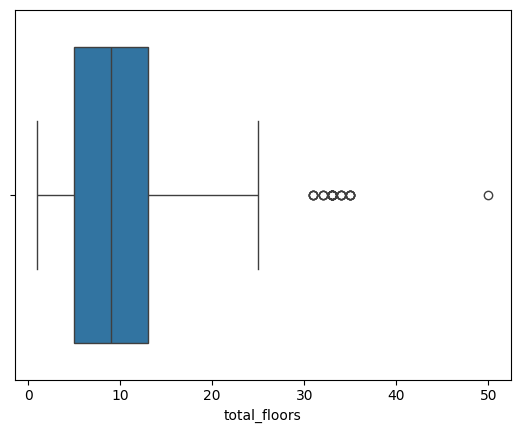

In [ ]:
# sns.displot(flat_df['total_floors'])
sns.boxplot(x=flat_df['total_floors'])
plt.show()

In [343]:
flat_df[
    (flat_df['total_floors'] > 25) &
    (~flat_df.index.isin(mask.index))
][['Name','current_floor','total_floors','Property_URL','is_super_built_up_area','is_built_up_area','is_carpet_area']]

,Name,current_floor,total_floors,Property_URL,is_super_built_up_area,is_built_up_area,is_carpet_area
134,"2 BHK Flatin Gift City, Gandhinagar",6.0,31.0,https://www.99acres.com/2-bhk-bedroom-apartment-flat-for-sale-in-sobha-avalon-gift-city-gandhinagar-1302-sqft-spid-N90876478,False,False,True
216,"3 BHK Flatin Gift City, Gandhinagar",NaN,34.0,https://www.99acres.com/3-bhk-bedroom-apartment-flat-for-sale-in-shivalik-skyview-gift-city-gandhinagar-2671-sqft-spid-P89720444,True,False,False
269,"1 BHK Flatin Gift City, Gandhinagar",7.0,33.0,https://www.99acres.com/1-bhk-bedroom-apartment-flat-for-sale-in-vida-by-nila-spaces-gift-city-gandhinagar-529-sqft-spid-O88689166,False,False,False
498,"3 BHK Flatin Gift City, Gandhinagar",NaN,35.0,https://www.99acres.com/3-bhk-bedroom-apartment-flat-for-sale-in-gift-city-gandhinagar-1426-sqft-r4-spid-E85608886,True,False,False
664,"3 BHK Flatin Gift City, Gandhinagar",NaN,35.0,https://www.99acres.com/3-bhk-bedroom-apartment-flat-for-sale-in-sobha-elysia-gift-city-gandhinagar-1977-sqft-spid-H90939168,True,False,False
751,"1 BHK Flatin Gift City, Gandhinagar",5.0,33.0,https://www.99acres.com/1-bhk-bedroom-apartment-flat-for-sale-in-vida-by-nila-spaces-gift-city-gandhinagar-1000-sqft-r11-spid-Z74870245,True,False,False
752,"3 BHK Flatin Gift City, Gandhinagar",9.0,33.0,https://www.99acres.com/3-bhk-bedroom-apartment-flat-for-sale-in-vida-by-nila-spaces-gift-city-gandhinagar-2020-sqft-r11-spid-I74870327,True,False,False
753,"1 BHK Flatin Gift City, Gandhinagar",8.0,33.0,https://www.99acres.com/1-bhk-bedroom-apartment-flat-for-sale-in-gift-city-gandhinagar-800-sqft-r11-spid-D74097269,True,False,False
821,"1 BHK Flatin Gift City, Gandhinagar",7.0,33.0,https://www.99acres.com/1-bhk-bedroom-apartment-flat-for-sale-in-vida-by-nila-spaces-gift-city-gandhinagar-529-sqft-spid-M90792018,False,False,True
877,"2 BHK Flatin Gift City, Gandhinagar",9.0,33.0,https://www.99acres.com/2-bhk-bedroom-apartment-flat-for-sale-in-sobha-dream-heights-gift-city-gandhinagar-1095-sqft-spid-A90223096,True,False,False


In [ ]:
flat_df.loc[216, ['current_floor', 'total_floors']] = [9, 34]
flat_df.loc[498, ['current_floor', 'total_floors']] = [13, 35]
flat_df.loc[664, ['current_floor', 'total_floors']] = [15, 35]

In [355]:
flat_df['pps']=round((flat_df['Price (INR in Lakhs)']*100000)/flat_df['Area_sqft'])

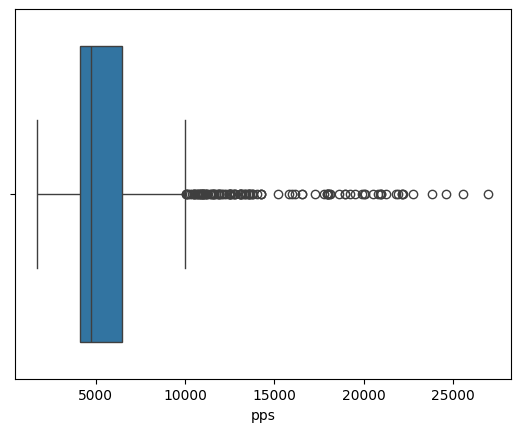

In [358]:
# sns.displot(flat_df['pps'])
sns.boxplot(x=flat_df['pps'])
plt.show()


In [360]:
flat_df[flat_df['pps']>23000][['Name','pps','Price (INR in Lakhs)','Price_per_sqft','Area_sqft','bedrooms','Property_URL','is_super_built_up_area','is_built_up_area','is_carpet_area']]

,Name,pps,Price (INR in Lakhs),Price_per_sqft,Area_sqft,bedrooms,Property_URL,is_super_built_up_area,is_built_up_area,is_carpet_area
321,"2 BHK Flatin Gift City, Gandhinagar",24603.0,155.0,24603.0,630.0,2.0,https://www.99acres.com/2-bhk-bedroom-apartment-flat-for-sale-in-sobha-dream-heights-gift-city-gandhinagar-1109-sq-ft-spid-O83241948,False,False,True
657,"2 BHK Flatin Gift City, Gandhinagar",23810.0,150.0,23810.0,630.0,2.0,https://www.99acres.com/2-bhk-bedroom-apartment-flat-for-sale-in-sobha-dream-heights-gift-city-gandhinagar-630-sqft-spid-W90864606,False,False,True
1013,"3 BHK Flatin Sector 6, Gandhinagar",25589.0,380.0,25589.0,1485.0,3.0,https://www.99acres.com/3-bhk-bedroom-apartment-flat-for-sale-in-sector-6-gandhinagar-1485-sqft-r1-spid-D81111325,False,True,False
1228,"2 BHK Flatin Gift City, Gandhinagar",26984.0,170.0,26984.0,630.0,2.0,https://www.99acres.com/2-bhk-bedroom-apartment-flat-for-sale-in-sobha-dream-heights-gift-city-gandhinagar-630-sqft-spid-R86509012,False,False,True


In [386]:
flat_df[
    flat_df['current_floor'] > flat_df['total_floors']
][['current_floor','total_floors']]

,current_floor,total_floors
254,23.0,13.0


In [387]:
flat_df.loc[254,'current_floor']=13

In [388]:
flat_df.groupby('bedrooms')['Area_sqft'].describe()

,count,mean,std,min,25%,50%,75%,max
bedrooms,,,,,,,,
0.0,20.0,1004.135500,475.873637,293.00,650.5425,942.585,1262.25,2109.000
1.0,109.0,667.802053,377.849194,210.00,483.0000,600.000,780.00,3204.000
2.0,555.0,1227.113567,344.460987,336.00,1017.0000,1242.000,1404.00,3552.087
3.0,522.0,1976.301860,565.476585,751.75,1676.2500,1980.000,2322.00,4410.000
4.0,90.0,3536.993812,1123.042427,644.00,2931.7500,3555.000,4158.00,7650.000
5.0,5.0,4585.600000,2112.833477,1400.00,4248.0000,4248.000,6399.00,6633.000
6.0,3.0,7125.000000,1627.690081,6075.00,6187.5000,6300.000,7650.00,9000.000


In [389]:
flat_df[
    ((flat_df['Bedrooms'] == 2) & (flat_df['Area_sqft'] < 500) & flat_df['is_carpet_area']==True) |
    ((flat_df['Bedrooms'] == 3) & (flat_df['Area_sqft'] < 1000) & flat_df['is_carpet_area']==True) |
    ((flat_df['Bedrooms'] == 4) & (flat_df['Area_sqft'] < 1500) & flat_df['is_carpet_area']==True)
][['Name','Bedrooms','Area_sqft','Price_per_sqft','Property_URL']]

,Name,Bedrooms,Area_sqft,Price_per_sqft,Property_URL
8,"3 BHK Flatin Kudasan, Gandhinagar",3.0,980.000000,7653.000000,https://www.99acres.com/3-bhk-bedroom-apartment-flat-for-sale-in-psy-pramukh-signature-kudasan-gandhinagar-980-sqft-spid-G91130676
53,"3 BHK Flatin Sargasan, Gandhinagar",3.0,791.000000,9475.000000,https://www.99acres.com/3-bhk-bedroom-apartment-flat-for-sale-in-shreeji-sahajanand-shayona-sargasan-gandhinagar-792-sqft-spid-G88471194
117,"3 BHK Flatin Sargasan, Gandhinagar",3.0,955.000000,13089.000000,https://www.99acres.com/3-bhk-bedroom-apartment-flat-for-sale-in-aavkar-96-sargasan-gandhinagar-10280-sqft-spid-K91150552
132,"3 BHK Flatin Randheja, Gandhinagar",3.0,950.000000,5789.000000,https://www.99acres.com/3-bhk-bedroom-apartment-flat-for-sale-in-polaris-elina-randheja-gandhinagar-950-sqft-spid-Z90915948
139,"3 BHK Flatin Sughad, Gandhinagar",3.0,950.000000,9473.000000,https://www.99acres.com/3-bhk-bedroom-apartment-flat-for-sale-in-gandhinagar-950-sqft-spid-L90800992
151,"3 BHK Flatin Karai, Gandhinagar",3.0,850.000000,8470.000000,https://www.99acres.com/3-bhk-bedroom-apartment-flat-for-sale-in-karai-gandhinagar-850-sqft-spid-B90563372
172,"3 BHK Flatin Randesan, Gandhinagar",3.0,945.000000,9838.000000,https://www.99acres.com/3-bhk-bedroom-apartment-flat-for-sale-in-royal-riviera-randesan-gandhinagar-945-sqft-spid-S90294290
203,"3 BHK Flatin Sargasan, Gandhinagar",3.0,786.000000,9154.000000,https://www.99acres.com/3-bhk-bedroom-apartment-flat-for-sale-in-shreeji-sahajanand-shayona-sargasan-gandhinagar-787-sqft-spid-K89866680
214,"3 BHK Flatin Raysan, Gandhinagar",3.0,881.000000,8967.000000,https://www.99acres.com/3-bhk-bedroom-apartment-flat-for-sale-in-bhavya-devanshi-prime-raysan-gandhinagar-881-sqft-spid-C89744254
231,"3 BHK Flatin Sargasan, Gandhinagar",3.0,786.000000,9154.000000,https://www.99acres.com/3-bhk-bedroom-apartment-flat-for-sale-in-shreeji-sahajanand-shayona-sargasan-gandhinagar-787-sqft-spid-B89318531


In [394]:
(flat_df['Area_sqft']/flat_df['Bedrooms']).quantile(0.01)

np.float64(256.93333333333334)

In [397]:
flat_df[(flat_df['Area_sqft']/flat_df['Bedrooms'])<256][['Name','Bedrooms','Price (INR in Lakhs)','Area_sqft','Price_per_sqft','Property_URL']]

,Name,Bedrooms,Price (INR in Lakhs),Area_sqft,Price_per_sqft,Property_URL
284,"3 BHK Builder Floorin Pethapur, Gandhinagar",3.0,35.0,678.125700,5161.284995,https://www.99acres.com/3-bhk-bedroom-independent-builder-floor-for-sale-in-pethapur-gandhinagar-63-sqft-spid-L87717098
807,"4 BHK Flatin Gift City, Gandhinagar",4.0,135.0,644.000000,20963.000000,https://www.99acres.com/4-bhk-bedroom-apartment-flat-for-sale-in-gift-city-gandhinagar-644-sqft-spid-V91151430
1124,"3 BHK Flatin Randheja, Gandhinagar",3.0,69.0,672.390000,10262.000000,https://www.99acres.com/3-bhk-bedroom-apartment-flat-for-sale-in-polaris-elina-randheja-gandhinagar-6930-sqft-spid-U87884776
1128,"2 BHK Flatin Vavol, Gandhinagar",2.0,45.0,496.753985,9058.810067,https://www.99acres.com/2-bhk-bedroom-apartment-flat-for-sale-in-skj-siddharth-skyz-vavol-gandhinagar-46-sqft-spid-G87855144
1133,"2 BHK Flatin Vavol, Gandhinagar",2.0,45.0,496.753985,9058.810067,https://www.99acres.com/2-bhk-bedroom-apartment-flat-for-sale-in-skj-siddharth-skyz-vavol-gandhinagar-46-sqft-spid-M87829126
1136,"Studio Apartments / 1 RK Flatsin Sector 24, Gandhinagar",1.0,15.0,210.000000,7143.000000,https://www.99acres.com/studio-apartment-flat-for-sale-in-sector-24-gandhinagar-210-sqft-spid-O87809336
1184,"2 BHK Flatin Vavol, Gandhinagar",2.0,45.0,500.000000,9000.000000,https://www.99acres.com/2-bhk-bedroom-apartment-flat-for-sale-in-aakar-shalvik-shukan-vavol-gandhinagar-500-sqft-spid-E87354784
1234,"2 BHK Flatin Kalol, Gandhinagar",2.0,24.0,446.000000,5381.000000,https://www.99acres.com/2-bhk-bedroom-apartment-flat-for-sale-in-tata-shubh-griha-kalol-gandhinagar-446-sqft-spid-J86454342
1235,"2 BHK Flatin Kalol, Gandhinagar",2.0,24.0,500.000000,4800.000000,https://www.99acres.com/2-bhk-bedroom-apartment-flat-for-sale-in-tata-shubh-griha-kalol-gandhinagar-500-sqft-spid-S86454238
1255,"3 BHK Flatin Vavol, Gandhinagar",3.0,60.0,751.750000,7981.000000,https://www.99acres.com/3-bhk-bedroom-apartment-flat-for-sale-in-shivaay-the-spenta-vavol-gandhinagar-752-sqft-spid-O86171436


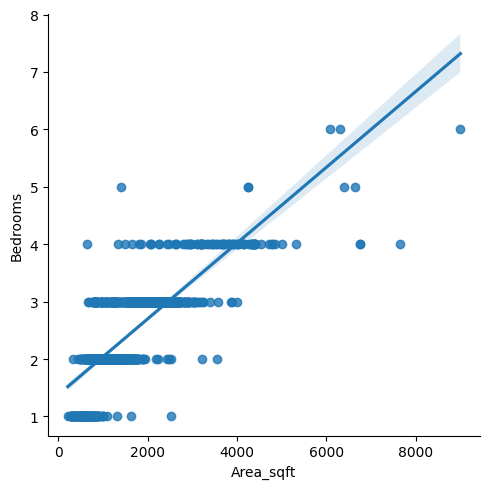

In [398]:
sns.lmplot(x='Area_sqft',y='Bedrooms',data=flat_df)

In [404]:
flat_df.drop(index=[1288, 807], inplace=True)

In [407]:
flat_df.drop(columns=['Balconies','Bathrooms'], inplace=True)

In [3]:
def missing_value_report(df):
    report = pd.DataFrame({
        'Missing Count': df.isna().sum(),
        'Missing %': round((df.isna().sum()/len(df))*100,2),
        'Data Type': df.dtypes
    })

    report = report[report['Missing Count'] > 0]
    return report.sort_values('Missing %', ascending=False)


In [4]:
missing_value_report(flat_df)

,Missing Count,Missing %,Data Type
facing,848,65.03,str
furnishing_status,677,51.92,str
total_floors,577,44.25,float64
current_floor,537,41.18,float64
luxury_score,101,7.75,float64
Description,101,7.75,str
location_advantage_score,101,7.75,float64
bedrooms,2,0.15,float64


In [413]:
flat_df['property_age_bucket'].value_counts()

property_age_bucket
New            620
Unknown        340
1-5 years      165
5-10 years     119
10-20 years     60
Name: count, dtype: int64

In [415]:
flat_df.info()

<class 'pandas.DataFrame'>
Index: 1304 entries, 0 to 1318
Data columns (total 24 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Name                      1304 non-null   str    
 1   Location                  1304 non-null   str    
 2   Price (INR in Lakhs)      1304 non-null   float64
 3   Price_per_sqft            1304 non-null   float64
 4   Area_sqft                 1304 non-null   float64
 5   Description               1203 non-null   str    
 6   Property_URL              1304 non-null   str    
 7   bathrooms                 1304 non-null   float64
 8   balconies                 1304 non-null   float64
 9   current_floor             767 non-null    float64
 10  total_floors              727 non-null    float64
 11  furnishing_status         627 non-null    str    
 12  Mapped_Area               1304 non-null   str    
 13  facing                    456 non-null    str    
 14  property_age_bucket     

In [414]:
flat_df.drop(columns=['bedrooms','log_price'], inplace=True)

In [420]:
flat_df[flat_df['property_age_bucket']=='Unknown'][['Name','Price (INR in Lakhs)','Price_per_sqft','Area_sqft','Bedrooms','Property_URL','is_super_built_up_area','is_built_up_area','is_carpet_area']]

,Name,Price (INR in Lakhs),Price_per_sqft,Area_sqft,Bedrooms,Property_URL,is_super_built_up_area,is_built_up_area,is_carpet_area
12,"2 BHK Flatin Raysan, Gandhinagar",59.0,4149.0,1422.0,2.0,https://www.99acres.com/2-bhk-bedroom-apartment-flat-for-sale-in-sre-luvkush-4-raysan-gandhinagar-1422-sqft-spid-V88148666,True,False,False
15,"2 BHK Flatin Gift City, Gandhinagar",155.0,17822.0,1581.0,2.0,https://www.99acres.com/2-bhk-bedroom-apartment-flat-for-sale-in-shivalik-skyview-gift-city-gandhinagar-1582-sqft-spid-K90727598,True,False,False
25,"3 BHK Flatin Kudasan, Gandhinagar",145.0,7435.0,3230.0,3.0,https://www.99acres.com/3-bhk-bedroom-apartment-flat-for-sale-in-shivalay-parisar-kudasan-gandhinagar-3230-sqft-spid-T88403926,True,False,False
34,"3 BHK Flatin Kudasan, Gandhinagar",78.0,3939.0,1980.0,3.0,https://www.99acres.com/3-bhk-bedroom-apartment-flat-for-sale-in-kudasan-gandhinagar-1980-sqft-r1-spid-W88630582,True,False,False
36,"3 BHK Flatin Raysan, Gandhinagar",125.0,5490.0,2277.0,3.0,https://www.99acres.com/3-bhk-bedroom-apartment-flat-for-sale-in-satvan-bellevue-raysan-gandhinagar-2277-sqft-spid-I90702252,True,False,False
...,...,...,...,...,...,...,...,...,...
1314,"2 BHK Flatin Vavol, Gandhinagar",40.0,3065.0,1305.0,2.0,https://www.99acres.com/2-bhk-bedroom-apartment-flat-for-sale-in-vavol-gandhinagar-1305-sqft-spid-P83931222,False,False,True
1315,"Residential propertyin Vavol, Gandhinagar",32.0,3200.0,1000.0,2.0,https://www.99acres.com/other-residential-property-for-sale-in-vavol-gandhinagar-1000-sqft-spid-Y83883628,False,False,False
1316,"3 BHK Builder Floorin Gift City, Gandhinagar",90.0,3913.0,2300.0,3.0,https://www.99acres.com/3-bhk-bedroom-independent-builder-floor-for-sale-in-gift-city-gandhinagar-2300-sqft-spid-N83780390,False,True,False
1317,3 BHK Flatin Gandhinagar Randheja Highway,78.0,3852.0,2025.0,3.0,https://www.99acres.com/3-bhk-bedroom-apartment-flat-for-sale-in-bansari-greencity-gandhinagar-2025-sqft-spid-L83616222,False,False,True


In [422]:
pd.crosstab(
    flat_df['Mapped_Area'],
    flat_df['property_age_bucket'],
    normalize='index'
)

property_age_bucket,1-5 years,10-20 years,5-10 years,New,Unknown
Mapped_Area,,,,,
Adalaj,0.000000,0.000000,0.000000,0.666667,0.333333
Ambapur,0.000000,0.000000,0.000000,1.000000,0.000000
Chiloda,0.000000,0.125000,0.000000,0.250000,0.625000
Dahegam,0.000000,0.000000,0.000000,0.666667,0.333333
Gandhinagar Taluka,0.166667,0.000000,0.000000,0.666667,0.166667
Gift City,0.043478,0.000000,0.000000,0.543478,0.413043
Kalol,0.090909,0.054545,0.145455,0.309091,0.400000
Karai,0.000000,0.000000,0.000000,0.750000,0.250000
Khoraj,0.000000,0.000000,0.000000,0.866667,0.133333


In [423]:
pd.crosstab(
    flat_df['property_type'],
    flat_df['property_age_bucket'],
    normalize='index'
)

property_age_bucket,1-5 years,10-20 years,5-10 years,New,Unknown
property_type,,,,,
apartment,0.128878,0.046937,0.093079,0.470167,0.260939
builder floor,0.093750,0.031250,0.062500,0.531250,0.281250
penthouse,0.000000,0.000000,0.000000,0.800000,0.200000


In [426]:
flat_df[flat_df['property_age_bucket'] == 'Unknown']['is_ready_to_move'].value_counts()

is_ready_to_move
1    265
0     75
Name: count, dtype: int64

In [427]:
pd.crosstab(
    flat_df['property_age_bucket'],
    flat_df['is_ready_to_move'],
    normalize='index'
)

is_ready_to_move,0,1
property_age_bucket,,
1-5 years,0.000000,1.000000
10-20 years,0.000000,1.000000
5-10 years,0.008403,0.991597
New,0.269355,0.730645
Unknown,0.220588,0.779412


In [428]:
pd.crosstab(
    flat_df[flat_df['property_age_bucket']=='Unknown']['property_type'],
    flat_df[flat_df['property_age_bucket']=='Unknown']['is_ready_to_move']
)

is_ready_to_move,0,1
property_type,,
apartment,75,253
builder floor,0,9
penthouse,0,3


**Property age was kept as "Unknown" instead of imputing it because the missing values do not appear to be random. Around 340 properties have an unknown age, which is a significant portion of the dataset. Analysis showed that these properties have a different distribution of ready-to-move status compared to other age categories. Therefore, replacing them with the mode could introduce incorrect information. Keeping "Unknown" as a separate category preserves the original information and allows the model to learn any pattern associated with undisclosed property age.**


In [ ]:
# flat_df['facing'].value_counts()


facing
East          283
North-East     67
Other          53
West           21
North          13
South-East      6
North-West      5
South           4
South-West      4
Name: count, dtype: int64

In [432]:
pd.crosstab(
    flat_df['property_type'],
    flat_df['facing'].isna(),
    normalize='index'
)

facing,False,True
property_type,,
apartment,0.361973,0.638027
builder floor,0.031250,0.968750
penthouse,0.000000,1.000000


In [433]:
pd.crosstab(
    flat_df['is_ready_to_move'],
    flat_df['facing'].isna(),
    normalize='index'
)

facing,False,True
is_ready_to_move,,
0,0.386831,0.613169
1,0.341188,0.658812


In [434]:
flat_df['facing'].value_counts(normalize=True)

facing
East          0.620614
North-East    0.146930
Other         0.116228
West          0.046053
North         0.028509
South-East    0.013158
North-West    0.010965
South         0.008772
South-West    0.008772
Name: proportion, dtype: float64

In [5]:
flat_df['facing'] = flat_df['facing'].fillna('Unknown')

The facing column was not imputed. Missing values were replaced with a separate category, Unknown. The column has a very high missing rate (65%), and the missingness is not strongly associated with property type or ready-to-move status. Additionally, the observed facing distribution is highly imbalanced, with East-facing properties dominating the known values. Therefore, imputing missing values would likely introduce bias, while keeping Unknown preserves the original information.

In [438]:
flat_df['furnishing_status'].value_counts(normalize=True)

furnishing_status
unfurnished       0.657097
semi-furnished    0.188198
furnished         0.154705
Name: proportion, dtype: float64

In [439]:
pd.crosstab(
    flat_df['property_type'],
    flat_df['furnishing_status'].isna(),
    normalize='index'
)

furnishing_status,False,True
property_type,,
apartment,0.476531,0.523469
builder floor,0.781250,0.218750
penthouse,0.200000,0.800000


In [440]:
pd.crosstab(
    flat_df['is_ready_to_move'],
    flat_df['furnishing_status'].isna(),
    normalize='index'
)

furnishing_status,False,True
is_ready_to_move,,
0,0.234568,0.765432
1,0.537229,0.462771


In [441]:
pd.crosstab(
    flat_df['furnishing_status'],
    flat_df['property_type'],
    normalize='columns'
)

property_type,apartment,builder floor,penthouse
furnishing_status,,,
furnished,0.151920,0.20,0.333333
semi-furnished,0.180301,0.32,0.666667
unfurnished,0.667780,0.48,0.000000


In [442]:
flat_df[flat_df['furnishing_status'].isna()][['Name','Price (INR in Lakhs)','Price_per_sqft','Area_sqft','Bedrooms','Property_URL','is_super_built_up_area','is_built_up_area','is_carpet_area']]

,Name,Price (INR in Lakhs),Price_per_sqft,Area_sqft,Bedrooms,Property_URL,is_super_built_up_area,is_built_up_area,is_carpet_area
0,"3 BHK Flatin Sargasan, Gandhinagar",126.00,4320.0,2916.0,3.0,https://www.99acres.com/3-bhk-bedroom-apartment-flat-for-sale-in-altezza-by-the-palm-sargasan-gandhinagar-2916-sqft-npspid-V89041074,True,False,False
1,"3 BHK Flatin Pethapur, Gandhinagar",51.99,2962.0,1755.0,3.0,https://www.99acres.com/3-bhk-bedroom-apartment-flat-for-sale-in-satyamev-royal-5-pethapur-gandhinagar-1755-sqft-npspid-V87599244,True,False,False
2,"3 BHK Flatin Raysan, Gandhinagar",97.00,5083.0,1908.0,3.0,https://www.99acres.com/3-bhk-bedroom-apartment-flat-for-sale-in-radhe-imperial-sky-raysan-gandhinagar-1908-sqft-spid-R89058182,True,False,False
3,"3 BHK Flatin Raysan, Gandhinagar",125.00,5669.0,2205.0,3.0,https://www.99acres.com/3-bhk-bedroom-apartment-flat-for-sale-in-raysan-gandhinagar-2205-sqft-spid-R90201698,False,False,True
5,"3 BHK Flatin Koba, Gandhinagar",120.00,4848.0,2475.0,3.0,https://www.99acres.com/3-bhk-bedroom-apartment-flat-for-sale-in-bliss-bansari-opulence-koba-gandhinagar-2475-sqft-spid-W88788888,True,False,False
...,...,...,...,...,...,...,...,...,...
1314,"2 BHK Flatin Vavol, Gandhinagar",40.00,3065.0,1305.0,2.0,https://www.99acres.com/2-bhk-bedroom-apartment-flat-for-sale-in-vavol-gandhinagar-1305-sqft-spid-P83931222,False,False,True
1315,"Residential propertyin Vavol, Gandhinagar",32.00,3200.0,1000.0,2.0,https://www.99acres.com/other-residential-property-for-sale-in-vavol-gandhinagar-1000-sqft-spid-Y83883628,False,False,False
1316,"3 BHK Builder Floorin Gift City, Gandhinagar",90.00,3913.0,2300.0,3.0,https://www.99acres.com/3-bhk-bedroom-independent-builder-floor-for-sale-in-gift-city-gandhinagar-2300-sqft-spid-N83780390,False,True,False
1317,3 BHK Flatin Gandhinagar Randheja Highway,78.00,3852.0,2025.0,3.0,https://www.99acres.com/3-bhk-bedroom-apartment-flat-for-sale-in-bansari-greencity-gandhinagar-2025-sqft-spid-L83616222,False,False,True


In [6]:
flat_df['furnishing_status']=flat_df['furnishing_status'].fillna('Unknown')

The missing values in furnishing_status were replaced with Unknown. More than half of the values were missing, and the missingness was not random, as under-construction properties had a significantly higher missing rate than ready-to-move properties. Since furnishing status cannot be reliably inferred from other available features, keeping Unknown preserves potentially useful information and avoids introducing incorrect labels.

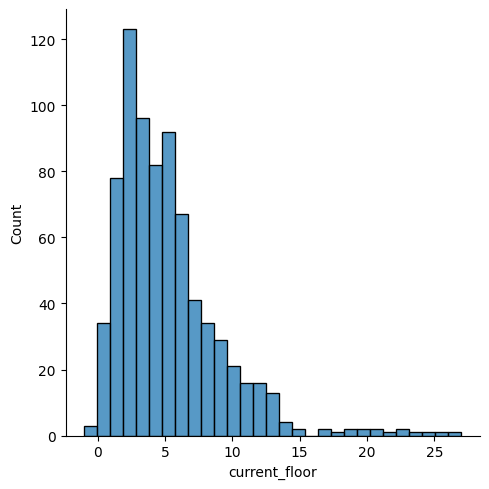

In [444]:
sns.displot(flat_df['current_floor'])
plt.show()

In [447]:
pd.crosstab(
    flat_df['property_type'],
    flat_df['current_floor'].isna(),
    normalize='index'
)

current_floor,False,True
property_type,,
apartment,0.593477,0.406523
builder floor,0.562500,0.437500
penthouse,0.200000,0.800000


In [448]:
pd.crosstab(
    flat_df['is_ready_to_move'],
    flat_df['current_floor'].isna(),
    normalize='index'
)

current_floor,False,True
is_ready_to_move,,
0,0.596708,0.403292
1,0.586239,0.413761


In [449]:
flat_df[
    flat_df['current_floor'].isna()
]['total_floors'].notna().mean()

np.float64(0.16201117318435754)

In [451]:
# flat_df.loc[
#     flat_df['current_floor'].isna(),
#     'Description'
# ].dropna().sample(20, random_state=42)

In [7]:
top_floor_mask = (
    flat_df['current_floor'].isna() &
    flat_df['Description'].str.contains(
        r'top floor',
        case=False,
        na=False
    )
)

In [8]:
flat_df.loc[top_floor_mask, 'current_floor'] = (
    flat_df.loc[top_floor_mask, 'total_floors']
)

In [459]:
before = flat_df['current_floor'].isna().sum()
before

np.int64(483)

In [9]:
flat_df['desc_clean'] = (
    flat_df['Description']
    .fillna('')
    .str.lower()
    .str.replace(r'\s+', ' ', regex=True)
)

In [10]:
import re

In [11]:
def extract_current_floor(text):
    if pd.isna(text):
        return np.nan

    text = str(text).lower()

    match = re.search(r'(\d+)\s*(?:st|nd|rd|th)\s*floor', text)

    if match:
        return int(match.group(1))

    return np.nan

flat_df['current_floor_extracted'] = flat_df['desc_clean'].apply(extract_current_floor)

In [12]:
def extract_ground_floor(text):
    if pd.isna(text):
        return np.nan

    text = str(text).lower()

    if 'ground floor' in text:
        return 0      

    return np.nan


ground_floor = flat_df['desc_clean'].apply(extract_ground_floor)

flat_df['current_floor_extracted'] = (
    flat_df['current_floor_extracted']
    .fillna(ground_floor)
)

In [13]:
top_floor_mask = (
   flat_df['desc_clean']
      .fillna('')
      .str.lower()
      .str.contains(
          r'top floor|topmost floor|highest floor|last floor',
          regex=True
      )
)

flat_df.loc[
    top_floor_mask &
   flat_df['total_floors'].notna(),
    'current_floor_extracted'
] =flat_df.loc[
    top_floor_mask &
   flat_df['total_floors'].notna(),
    'total_floors'
]

In [14]:
mask = (
    flat_df['current_floor'].isna() &
    flat_df['current_floor_extracted'].notna()
)

flat_df.loc[mask, 'current_floor'] = flat_df.loc[
    mask,
    'current_floor_extracted'
]

In [16]:
after = flat_df['current_floor'].isna().sum()

# print("Recovered:", before - after)
print("Remaining:", after)

Remaining: 475


In [17]:
top_floor_mask = (
    flat_df['current_floor'].isna() &
    flat_df['desc_clean'].str.contains(
        r'\btop floor\b',
        regex=True,
        na=False
    ) &
    flat_df['total_floors'].notna()
)

flat_df.loc[top_floor_mask, 'current_floor'] = \
    flat_df.loc[top_floor_mask, 'total_floors']

In [18]:
flat_df.groupby('current_floor')['Price (INR in Lakhs)'].median().head(20)

current_floor
-1.0      68.0
 0.0      82.5
 1.0      59.7
 2.0      65.0
 3.0      65.0
 4.0      71.0
 5.0      70.0
 6.0      88.5
 7.0      72.0
 8.0      84.0
 9.0     114.0
 10.0    104.0
 11.0     90.0
 12.0     99.5
 13.0    110.0
 14.0    142.0
 15.0    152.5
 17.0    139.5
 18.0    110.0
 19.0    207.5
Name: Price (INR in Lakhs), dtype: float64

In [475]:
flat_df.groupby(['Mapped_Area'])['current_floor'].median().sort_values()

Mapped_Area
Sector 19             0.0
Sector 22             0.0
Sector 29             0.0
Sector 11             0.0
Sector 6              1.0
Adalaj                2.0
Chiloda               2.0
Ambapur               2.0
Kalol                 2.0
Pethapur              3.0
Vavol                 3.0
Randheja              3.0
Kolavada              3.0
Raysan                4.0
Kudasan               4.0
Koba                  4.0
Sargasan              4.0
Karai                 4.5
Gandhinagar Taluka    4.5
Randesan              5.0
Dahegam               5.5
Uvarsad               6.0
Sector 26             7.0
Khoraj                8.0
SP Ring Road          8.0
Other                 8.0
Gift City             9.0
SG Highway            NaN
Sector 21             NaN
Sector 24             NaN
Sector 28             NaN
Sector 8              NaN
Sughad                NaN
Valad                 NaN
Name: current_floor, dtype: float64

In [476]:
flat_df.groupby(['property_type'])['current_floor'].median()

property_type
apartment        4.0
builder floor    2.0
penthouse        7.0
Name: current_floor, dtype: float64

In [477]:
flat_df[['current_floor','total_floors']].corr()

,current_floor,total_floors
current_floor,1.000000,0.670395
total_floors,0.670395,1.000000


In [478]:
flat_df.groupby('total_floors')['current_floor'].median()

total_floors
1.0      0.0
2.0      2.0
3.0      2.0
4.0      2.0
5.0      3.0
6.0      4.0
7.0      4.5
8.0      4.0
9.0      4.0
10.0     5.0
11.0     7.0
12.0     4.0
13.0     6.0
14.0     7.0
15.0     6.5
16.0    10.0
17.0    10.5
18.0     6.0
19.0     4.0
20.0     7.5
21.0     5.5
22.0     6.0
24.0     8.0
25.0     7.5
31.0    14.5
32.0    14.0
33.0    14.0
34.0    13.0
35.0    15.0
50.0    13.0
Name: current_floor, dtype: float64

In [19]:
flat_df['current_floor'] = flat_df['current_floor'].replace(-1, 0)

In [482]:
flat_df[flat_df['current_floor'].isna()][['Name','Price (INR in Lakhs)','Price_per_sqft','Area_sqft','Bedrooms','Property_URL','is_super_built_up_area','is_built_up_area','is_carpet_area']].shape

(475, 9)

In [20]:
mask = flat_df['current_floor'].isna()

flat_df.loc[mask, 'total_floors'].notna().mean()

np.float64(0.06947368421052631)

In [486]:
(
    flat_df.groupby(['Mapped_Area','property_type'])
      ['current_floor']
      .count()
      .describe()
)

count     50.000000
mean      16.580000
std       45.046955
min        0.000000
25%        1.000000
50%        2.000000
75%        7.250000
max      287.000000
Name: current_floor, dtype: float64

In [487]:
flat_df.groupby(['Bedrooms'])['current_floor'].median()

Bedrooms
1.0     2.0
2.0     4.0
3.0     5.0
4.0     6.0
5.0     6.5
6.0    10.0
Name: current_floor, dtype: float64

In [21]:
flat_df['current_floor'] = flat_df['current_floor'].fillna(
    flat_df.groupby('total_floors')['current_floor']
      .transform('median')
)

flat_df['current_floor'] = flat_df['current_floor'].fillna(
    flat_df.groupby('Mapped_Area')['current_floor']
      .transform('median')
)

flat_df['current_floor'] = flat_df['current_floor'].fillna(
    flat_df.groupby('property_type')['current_floor']
      .transform('median')
)

flat_df['current_floor'] = flat_df['current_floor'].fillna(
    flat_df.groupby('Bedrooms')['current_floor']
      .transform('median')
)

flat_df['current_floor'] = flat_df['current_floor'].fillna(
    flat_df['current_floor'].median()
)

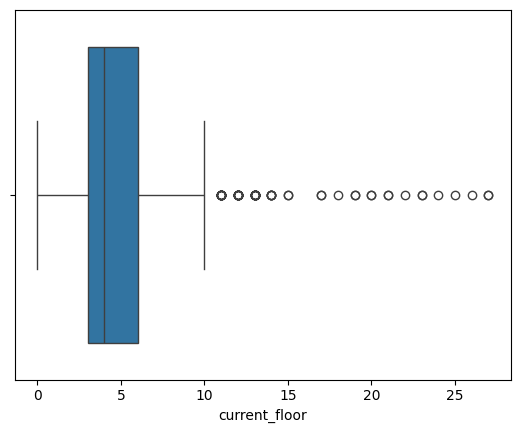

In [22]:
# sns.displot(flat_df['current_floor'])
sns.boxplot(x=flat_df['current_floor'])
plt.show()

In [501]:
flat_df['total_floors'].isna().sum()

np.int64(577)

In [502]:
pd.crosstab(
    flat_df['property_type'],
    flat_df['total_floors'].isna(),
    normalize='index'
)

total_floors,False,True
property_type,,
apartment,0.560859,0.439141
builder floor,0.656250,0.343750
penthouse,0.066667,0.933333


In [503]:
pd.crosstab(
    flat_df['is_ready_to_move'],
    flat_df['total_floors'].isna(),
    normalize='index'
)

total_floors,False,True
is_ready_to_move,,
0,0.584362,0.415638
1,0.551367,0.448633


In [504]:
mask = flat_df['total_floors'].isna()

flat_df.loc[mask, 'current_floor'].notna().mean()

np.float64(1.0)

In [505]:
flat_df.groupby('Mapped_Area')['total_floors'].median().sort_values()

Mapped_Area
Sector 6               1.0
Sector 22              3.5
Sector 29              4.0
Dahegam                5.0
Pethapur               5.0
Chiloda                5.0
Kalol                  5.0
Gandhinagar Taluka     5.0
Vavol                  6.0
Randheja               7.0
Sector 26              7.0
Sector 8               7.0
Adalaj                 7.5
Kudasan                8.0
Raysan                 9.0
Other                  9.0
Valad                  9.0
Sargasan              10.0
Koba                  12.0
Karai                 12.0
Randesan              12.0
Uvarsad               13.0
Ambapur               13.0
SP Ring Road          13.5
Khoraj                20.0
Gift City             25.0
Kolavada               NaN
SG Highway             NaN
Sector 11              NaN
Sector 19              NaN
Sector 21              NaN
Sector 24              NaN
Sector 28              NaN
Sughad                 NaN
Name: total_floors, dtype: float64

In [506]:
flat_df.groupby(['property_type'])['total_floors'].median()

property_type
apartment        9.0
builder floor    5.0
penthouse        5.0
Name: total_floors, dtype: float64

In [507]:
flat_df.groupby('Bedrooms')['total_floors'].median()

Bedrooms
1.0     5.0
2.0     7.0
3.0    12.0
4.0    13.0
5.0     2.0
6.0    20.0
Name: total_floors, dtype: float64

In [508]:
(
    flat_df.groupby('Mapped_Area')['total_floors']
      .count()
      .describe()
)

count     34.000000
mean      21.382353
std       49.652742
min        0.000000
25%        1.000000
50%        2.000000
75%       12.000000
max      267.000000
Name: total_floors, dtype: float64

In [23]:
# Step 1
flat_df['total_floors'] = flat_df['total_floors'].fillna(
    flat_df.groupby('current_floor')['total_floors']
      .transform('median')
)

# Step 2
flat_df['total_floors'] = flat_df['total_floors'].fillna(
    flat_df.groupby('Mapped_Area')['total_floors']
      .transform('median')
)

# Step 3
flat_df['total_floors'] = flat_df['total_floors'].fillna(
    flat_df.groupby('property_type')['total_floors']
      .transform('median')
)

# Step 4
flat_df['total_floors'] = flat_df['total_floors'].fillna(
    flat_df.groupby('Bedrooms')['total_floors']
      .transform('median')
)

# Step 5
flat_df['total_floors'] = flat_df['total_floors'].fillna(
    flat_df['total_floors'].median()
)

In [ ]:
# flat_df['total_floors'].isna().sum()
# flat_df['current_floor'].isna().sum()

np.int64(0)

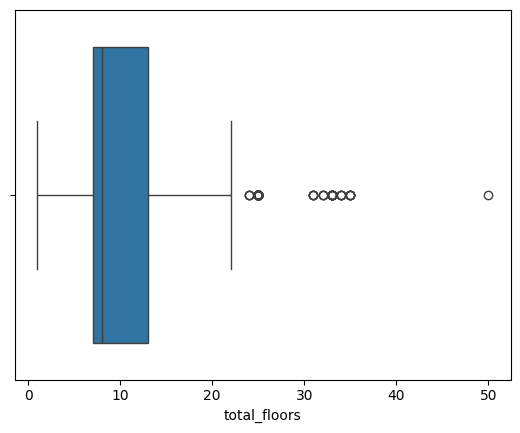

In [ ]:
# sns.displot(flat_df['total_floors'])
# sns.boxplot(x=flat_df['total_floors'])
# plt.show()

In [28]:
flat_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1304 entries, 0 to 1303
Data columns (total 26 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Name                      1304 non-null   str    
 1   Location                  1304 non-null   str    
 2   Price (INR in Lakhs)      1304 non-null   float64
 3   Price_per_sqft            1304 non-null   float64
 4   Area_sqft                 1304 non-null   float64
 5   Description               1203 non-null   str    
 6   Property_URL              1304 non-null   str    
 7   bedrooms                  1302 non-null   float64
 8   bathrooms                 1304 non-null   float64
 9   balconies                 1304 non-null   float64
 10  current_floor             1304 non-null   float64
 11  total_floors              1304 non-null   float64
 12  furnishing_status         1304 non-null   str    
 13  Mapped_Area               1304 non-null   str    
 14  facing             

In [27]:
flat_df.drop(
    columns=['desc_clean', 'current_floor_extracted'],
    inplace=True
)

In [522]:
diff_pct = (
    (flat_df['pps'] - flat_df['Price_per_sqft']).abs()
    / flat_df['Price_per_sqft']
) * 100

diff_pct.describe()

count    1304.000000
mean        1.183454
std         6.861839
min         0.000000
25%         0.000000
50%         0.000000
75%         0.011664
max        68.845566
dtype: float64

In [29]:
(
    flat_df.assign(
        diff=(flat_df['pps'] - flat_df['Price_per_sqft']).abs()
    )
    .sort_values('diff', ascending=False)
    [['Name',
      'Price (INR in Lakhs)',
      'Area_sqft',
      'pps',
      'Price_per_sqft',
      'diff']]
    .head(20)
)

,Name,Price (INR in Lakhs),Area_sqft,pps,Price_per_sqft,diff
15,"2 BHK Flatin Gift City, Gandhinagar",155.0,1581.0,9804.0,17822.0,8018.0
315,"2 BHK Flatin Gift City, Gandhinagar",142.0,1599.0,8881.0,16147.0,7266.0
148,"2 BHK Flatin Gift City, Gandhinagar",141.0,1590.0,8868.0,16120.0,7252.0
519,"4 BHK Builder Floorin Sargasan, Gandhinagar",115.0,2925.0,3932.0,11111.0,7179.0
606,"3 BHK Flatin Gift City, Gandhinagar",240.0,1876.0,12793.0,19580.0,6787.0
703,"3 BHK Flatin Kudasan, Gandhinagar",121.0,2565.0,4717.0,10206.0,5489.0
692,"3 BHK Flatin Sargasan, Gandhinagar",75.0,1800.0,4167.0,9259.0,5092.0
154,"3 BHK Flatin Sargasan, Gandhinagar",115.0,2142.0,5369.0,10244.0,4875.0
314,"3 BHK Flatin Kudasan, Gandhinagar",161.0,2250.0,7156.0,11926.0,4770.0
27,"2 BHK Flatin Kudasan, Gandhinagar",120.0,2232.0,5376.0,9732.0,4356.0


In [30]:
flat_df.to_csv("apartment_cleaned.csv", index=False)